# Boreal dynamics meta analysis with a focus on carbon accumulation

across multiple extents in different regions  

In [1]:
library(tidyverse)
library(data.table)
library(viridis)
library(sf)
library(mapproj)
library(rgdal)
library(raster)
library(aws.s3)
library(fs)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


Loading required package: viridisLite

Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE

Loading required package: maps


A

### Find the carbon accumulation monte carlo results

In [2]:
CACC_tindex_master_fn = 's3://maap-ops-workspace/shared/montesano/DPS_tile_lists/CACC/carbon_accumulation_v1/CACC_2020_v3.0_nsims050/CACC_tindex_master.csv'

## TEST - loop over only a few tiles..memory issues for full loop!

In [3]:
Sys.setenv("AWS_DEFAULT_REGION" = "us-west-2") 

# Read the tindex from s3
CACC_tindex_master <- aws.s3::s3read_using(read.csv, object = CACC_tindex_master_fn)
list_local_path <- CACC_tindex_master$local_path

pixel_data_fn_list = c()
monte_carlo_summary_data_fn_list = c()
summary_data_fn_list = c()

for(f in list_local_path[50:100]){
    tile_num_str = str_split(str_split(basename(f),'_')[[1]][4],'.tif')[[1]][1]
    tile_num = as.numeric(tile_num_str)
    #pixel_data_fn_list = c(pixel_data_fn_list, list.files(dirname(f), pattern = "^pixel_data_sample_.*\\.csv$", recursive=TRUE, full.names = TRUE))
    
    pixel_data_fn_list = c(pixel_data_fn_list, list.files(dirname(f), pattern = "^pixel_data_sample10pct.*\\.csv$", recursive=TRUE, full.names = TRUE))
    monte_carlo_summary_data_fn_list = c(monte_carlo_summary_data_fn_list, list.files(dirname(f), pattern = "^monte_carlo.*\\.csv$", recursive=TRUE, full.names = TRUE))
    summary_data_fn_list = c(summary_data_fn_list, list.files(dirname(f), pattern = "^summary_class.*\\.csv$", recursive=TRUE, full.names = TRUE))

    }

In [4]:
# N_SIMS = 5
# SEARCH_DIR = paste0('/projects/carbon_accumulation_analysis_v3/N_SIMS_',N_SIMS,'/tile/')

In [5]:
# pixel_data_fn_list = list.files(SEARCH_DIR, pattern = "^pixel_data_sample10pct.*\\.csv$", recursive=TRUE, full.names = TRUE)

In [6]:
# monte_carlo_summary_data_fn_list = list.files(SEARCH_DIR, pattern = "^monte_carlo.*\\.csv$", recursive=TRUE, full.names = TRUE)

In [7]:
# summary_data_fn_list = list.files(SEARCH_DIR, pattern = "^summary.*\\.csv$", recursive=TRUE, full.names = TRUE)

In [8]:
age_colors <- c(
    'non-forest' = 'gray',
    're-growth\n[1-36]' = '#e41a1c',
    'young\n[37-100]' = '#d9ef8b',
    'mature\n[101-150]' = '#5aae61',
    'old-growth\n[> 150]' = '#1b7837'
)
trend_colors <- c(
  'decline\n(strong)' = '#a6611a',
  'decline\n(weak)' = '#dfc27d',
  'stable' = '#d9d9d9', # '#bdbdbd',#'#f5f5f5',
  'increase\n(weak)' = '#80cdc1',
  'increase\n(strong)' = '#018571',
  'no trend\navailable' = 'black'
)
# Decid Frac Prediction
names_decidpred = c('conifer', 'mixed', 'deciduous')
colors_decidpred = c('#5e3c99','#fdb863','#ffffbf')
names(colors_decidpred) = names_decidpred

In [9]:
pixel_df_list <- list()
for (i in 1:length(pixel_data_fn_list)){
    pixel_df_list[[i]] = fread(pixel_data_fn_list[i])
    }
pixel_df <- do.call(rbind, pixel_df_list)
pixel_df_list = NULL

In [10]:
pixel_df = pixel_df %>% 
            mutate(
                age_class = factor(age_class, 
                              levels = c('non-forest','1-20', '21-36', '37-60', '61-80', '81-100', '101-150', '>150'),
                              ordered = TRUE),
                age_cohort = factor(age_cohort, 
                              levels = c('non-forest','re-growth forest','young forest', 'mature forest', 'old-growth forest'),
                              ordered = TRUE),
                trend_class = factor(trend_class,
                                levels = c('decline\n(strong)', 'decline\n(weak)', 'stable', 'increase\n(weak)', 'increase\n(strong)','no trend\navailable'),
                                ordered = TRUE)
                ) %>%
            mutate(
                age_cohort = fct_recode(age_cohort,
                               'non-forest' = 'non-forest',
                               're-growth\n[1-36]' = 're-growth forest',
                               'young\n[37-100]' = 'young forest' ,
                               'mature\n[101-150]' = 'mature forest', 
                               'old-growth\n[> 150]' = 'old-growth forest'        
                                         ))
#pixel_df[,'ecoregions_ECO_NAME'] <- factor(sub(' ', '\n', pixel_df[,'ecoregions_ECO_NAME']))

In [82]:
head(pixel_df)

row,col,biomass,biomass_std,age,age_std,carbon,carbon_std,carbon_acc,carbon_acc_std,⋯,pvalue_class_val,deciduous_class_val,age_class,trend_class,pvalue_class,deciduous_class,age_cohort,ecoregions_ECO_NAME,ecoregions_REALM,ID
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<ord>,<ord>,<chr>,<chr>,<ord>,<chr>,<chr>,<int>
2770,699,14.687279,22.5861130,0,0,8.3665346,10.1392335,0,0,⋯,0,0,non-forest,stable,not sig,conifer,non-forest,East Siberian taiga,PA,1709
288,1899,1.208662,0.4021478,0,0,0.6037269,0.1936397,0,0,⋯,NA,0,non-forest,no trend available,no trend available,conifer,non-forest,Taimyr-Central Siberian tundra,PA,1709
1200,1992,2.480610,1.2219280,0,0,1.2673713,0.5992331,0,0,⋯,NA,0,non-forest,no trend available,no trend available,conifer,non-forest,Taimyr-Central Siberian tundra,PA,1709
595,52,27.375397,6.1040764,0,0,14.1262901,3.4234762,0,0,⋯,0,0,non-forest,stable,not sig,conifer,non-forest,Taimyr-Central Siberian tundra,PA,1709
97,2459,2.010833,0.5553394,0,0,0.9760337,0.2684504,0,0,⋯,NA,0,non-forest,no trend available,no trend available,conifer,non-forest,Taimyr-Central Siberian tundra,PA,1709
2392,2147,1.500252,0.3234071,0,0,0.7504447,0.1620458,0,0,⋯,0,0,non-forest,stable,not sig,conifer,non-forest,Taimyr-Central Siberian tundra,PA,1709


In [137]:
source('/projects/code/maap_tools/lib/pixel_df_agg_uncertainty.r')

In [138]:
# Example usage with different pixel sizes

# Example 1: Default 30m pixels
cat("=== EXAMPLE 1: 30m x 30m pixels ===\n")
results_carbon <- analyze_existing_tile_data(
    pixel_df %>% mutate(tile_num = ID),
    STAT_mean = "carbon", STAT_sd = "carbon_std",
  pixel_size_m = 30
)

=== EXAMPLE 1: 30m x 30m pixels ===
Analyzing existing data with columns: carbon and carbon_std 
Using pixel size: 30 m x 30 m
Converting to Pg...Using pixel size: 30 m x 30 m
Pixel area: 900 m² ( 0.09 ha per pixel)


In [139]:
names(pixel_df)

[1] "row"                 "col"                 "biomass"            
 [4] "biomass_std"         "age"                 "age_std"            
 [7] "carbon"              "carbon_std"          "carbon_acc"         
[10] "carbon_acc_std"      "carbon_acc_ci_lower" "carbon_acc_ci_upper"
[13] "carbon_acc_pi_lower" "carbon_acc_pi_upper" "age_class_val"      
[16] "trend_class_val"     "pvalue_class_val"    "deciduous_class_val"
[19] "age_class"           "trend_class"         "pvalue_class"       
[22] "deciduous_class"     "age_cohort"          "ecoregions_ECO_NAME"
[25] "ecoregions_REALM"    "ID"

In [140]:
tail(results_carbon$domain_simple)

age_class,ecoregions_ECO_NAME,n_tiles,total_pixels,pixel_size_m,pixel_area_ha,total_area_m2,total_area_ha,total_area_km2,domain_total_STAT_mean,domain_total_STAT_variance,domain_total_STAT_sd,domain_STAT_per_m2_mean,domain_STAT_per_ha_mean,domain_STAT_per_m2_sd,domain_STAT_per_ha_sd,domain_cv,domain_ci_lower,domain_ci_upper,rse_percent
<ord>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
>150,Sakhalin Island taiga,2,227508,30,0.09,204757200,20475.72,204.7572,0.0121744916,1.473372e-11,3.838452e-06,5.945819e-11,5.945819e-07,1.874636e-14,1.874636e-10,0.03152865,0.0121669682,0.0121820149,0.03152865
>150,Scandinavian and Russian taiga,2,179097,30,0.09,161187300,16118.73,161.1873,0.0029729177,1.429046e-12,1.195427e-06,1.844387e-11,1.844387e-07,7.416386e-15,7.416386e-11,0.04021057,0.0029705746,0.0029752607,0.04021057
>150,Taimyr-Central Siberian tundra,2,30391,30,0.09,27351900,2735.19,27.3519,0.0002771055,1.250505e-13,3.536248e-07,1.013112e-11,1.013112e-07,1.292871e-14,1.292871e-10,0.12761378,0.0002764124,0.0002777986,0.12761378
>150,Trans-Baikal Bald Mountain tundra,3,4437,30,0.09,3993300,399.33,3.9933,0.0002844734,4.717807e-13,6.868629e-07,7.123767e-11,7.123767e-07,1.720038e-13,1.720038e-09,0.24145068,0.0002831271,0.0002858196,0.24145068
>150,Ussuri broadleaf and mixed forests,9,154255,30,0.09,138829500,13882.95,138.8295,0.0089109625,8.780537e-12,2.963197e-06,6.418638e-11,6.418638e-07,2.134415e-14,2.134415e-10,0.03325339,0.0089051546,0.0089167703,0.03325339
>150,West Siberian taiga,2,576504,30,0.09,518853600,51885.36,518.8536,0.0195205939,1.375711e-11,3.709058e-06,3.762255e-11,3.762255e-07,7.148564e-15,7.148564e-11,0.01900075,0.0195133241,0.0195278636,0.01900075


In [141]:
head(results_carbon$bootstrap_results)

age_class,bootstrap_mean,bootstrap_sd,bootstrap_ci_lower,bootstrap_ci_upper
<ord>,<dbl>,<dbl>,<dbl>,<dbl>
non-forest,0.1105030473,4.663649e-05,0.1104486311,0.1105655043
1-20,0.0819809166,5.258393e-05,0.0819202411,0.0820694806
21-36,0.0005113037,5.371707e-06,0.0005026644,0.0005183909
37-60,0.0098552550,1.717412e-05,0.0098331246,0.0098793509
61-80,0.0598140622,3.643545e-05,0.0597482747,0.0598620681
81-100,0.1716998768,9.291208e-05,0.1715669311,0.1718189049


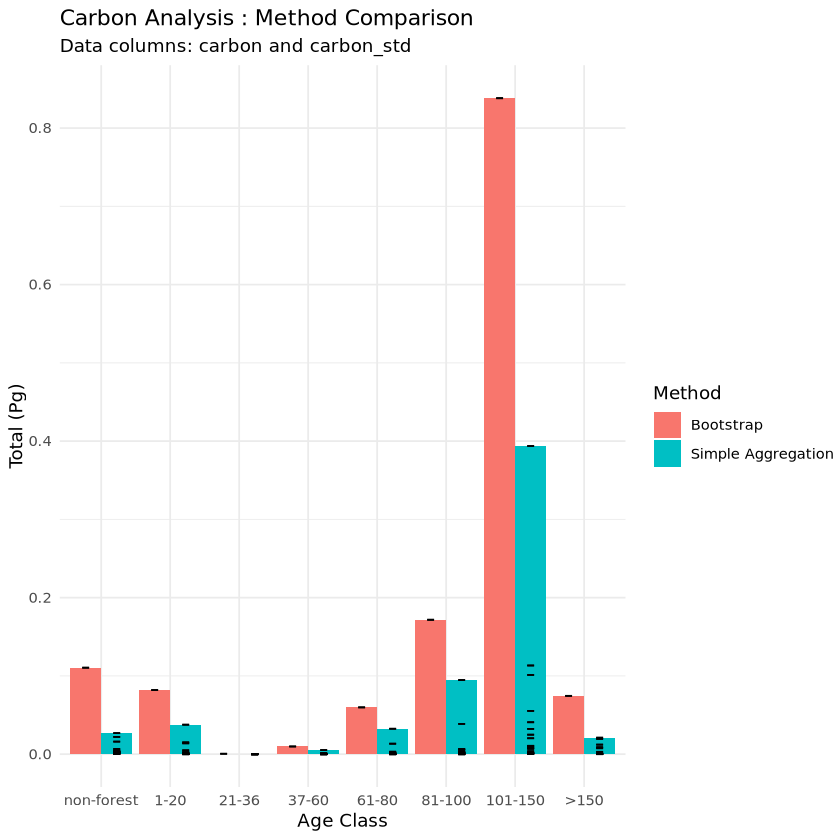

In [143]:
# Create plots for different analyses
create_flexible_plots(results_carbon, "Carbon Analysis")

In [96]:
sub(' ', '\n', levels(factor(pixel_df$ecoregions_ECO_NAME)))

[1] ""                                             
 [2] "Amur\nmeadow steppe"                          
 [3] "Cherskii-Kolyma\nmountain tundra"             
 [4] "Da\nHinggan-Dzhagdy Mountains conifer forests"
 [5] "Daurian\nforest steppe"                       
 [6] "East\nEuropean forest steppe"                 
 [7] "East\nSiberian taiga"                         
 [8] "Kamchatka-Kurile\nmeadows and sparse forests" 
 [9] "Manchurian\nmixed forests"                    
[10] "Northeast\nSiberian taiga"                    
[11] "Northwest\nRussian-Novaya Zemlya tundra"      
[12] "Okhotsk-Manchurian\ntaiga"                    
[13] "Sakhalin\nIsland taiga"                       
[14] "Sarmatic\nmixed forests"                      
[15] "Sayan\nmontane conifer forests"               
[16] "Scandinavian\nand Russian taiga"              
[17] "Selenge-Orkhon\nforest steppe"                
[18] "Taimyr-Central\nSiberian tundra"              
[19] "Trans-Baikal\nBald Mountain tundra"           
[20] "Trans-Baikal\nconifer forests"                
[21] "Ural\nmontane forests and tundra"             
[22] "Ussuri\nbroadleaf and mixed forests"          
[23] "West\nSiberian taiga"

In [97]:
levels(factor(pixel_df$ecoregions_ECO_NAME))

[1] ""                                            
 [2] "Amur meadow steppe"                          
 [3] "Cherskii-Kolyma mountain tundra"             
 [4] "Da Hinggan-Dzhagdy Mountains conifer forests"
 [5] "Daurian forest steppe"                       
 [6] "East European forest steppe"                 
 [7] "East Siberian taiga"                         
 [8] "Kamchatka-Kurile meadows and sparse forests" 
 [9] "Manchurian mixed forests"                    
[10] "Northeast Siberian taiga"                    
[11] "Northwest Russian-Novaya Zemlya tundra"      
[12] "Okhotsk-Manchurian taiga"                    
[13] "Sakhalin Island taiga"                       
[14] "Sarmatic mixed forests"                      
[15] "Sayan montane conifer forests"               
[16] "Scandinavian and Russian taiga"              
[17] "Selenge-Orkhon forest steppe"                
[18] "Taimyr-Central Siberian tundra"              
[19] "Trans-Baikal Bald Mountain tundra"           
[20] "Trans-Baikal conifer forests"                
[21] "Ural montane forests and tundra"             
[22] "Ussuri broadleaf and mixed forests"          
[23] "West Siberian taiga"

### Join all monte carlo C total data to summary data that has C accum totals

In [15]:
summary_df_list <- list()

for (i in 1:length(monte_carlo_summary_data_fn_list)){

    monte_carlo_data_fn = monte_carlo_summary_data_fn_list[i]
    summary_data_fn = summary_data_fn_list[i]
    common_cols = c('age_class','trend_class','pvalue_class','deciduous_class')

    # Extract tile_num from name
    #
    match <- regexpr("_([0-9]{7})\\.csv$", monte_carlo_data_fn, perl=TRUE)
    
    # Extract the matched substring
    matched_text <- regmatches(monte_carlo_data_fn, match)
    
    # Remove the underscore and .csv parts
    number_str <- gsub("_|.csv", "", matched_text)
    
    # Convert to integer
    tile_num <- as.integer(number_str)

    mc_df = fread(monte_carlo_data_fn)
    summary_df = fread(summary_data_fn)

    # Join monte carlo table to summary table
    df <- left_join(summary_df, mc_df, by = common_cols)
                  
    df$ID = tile_num

    # _ Pull this out of here and below (after do.call rbind) a groupby ecoregion
    ##### Get fractional area and fractional C
    # Compute percentages
    df$fractional_area = df$area_ha / sum(df$area_ha)
    df$fractional_C = df$total_carbon_Pg / sum(df$total_carbon_Pg)
    
    # Compute the cumulative percentages (top of each rectangle)
    df$ymax = cumsum(df$fractional_area)
    df$ymax_C = cumsum(df$fractional_C)
    
    # Compute the bottom of each rectangle
    df$ymin = c(0, head(df$ymax, n=-1))
    df$ymin_C = c(0, head(df$ymax_C, n=-1))
    
    summary_df_list[[i]] = df
    }

summary_df <- do.call(rbind, summary_df_list)

ERROR: Error in if (input == "" || length(grep("\\n|\\r", input))) {: missing value where TRUE/FALSE needed


In [ ]:
# summary_df_list <- list()

# for (i in 1:length(summary_data_fn_list)){

#     match <- regexpr("_([0-9]{7})\\.csv$", summary_data_fn_list[i], perl=TRUE)
    
#     # Extract the matched substring
#     matched_text <- regmatches(summary_data_fn_list[i], match)
    
#     # Remove the underscore and .csv parts
#     number_str <- gsub("_|.csv", "", matched_text)
    
#     # Convert to integer
#     tile_num <- as.integer(number_str)

#     df = fread(summary_data_fn_list[i])
#     df$ID = tile_num

#     # Get fractional area 
#     # Compute percentages
#     df$fraction = df$area_ha / sum(df$area_ha)
    
#     # Compute the cumulative percentages (top of each rectangle)
#     df$ymax = cumsum(df$fraction)
    
#     # Compute the bottom of each rectangle
#     df$ymin = c(0, head(df$ymax, n=-1))
    
#     summary_df_list[[i]] = df
#     }

# summary_df <- do.call(rbind, summary_df_list)

In [ ]:
summary_df = summary_df %>% 
            mutate(
                age_class = factor(age_class, 
                              levels = c('non-forest','1-20', '21-36', '37-60', '61-80', '81-100', '101-150', '>150'),
                              ordered = TRUE),
                age_cohort = factor(age_cohort, 
                              levels = c('non-forest','re-growth forest','young forest', 'mature forest', 'old-growth forest'),
                              ordered = TRUE),
                trend_class = factor(trend_class,
                                levels = c('decline\n(strong)', 'decline\n(weak)', 'stable', 'increase\n(weak)', 'increase\n(strong)','no trend\navailable'),
                                ordered = TRUE)
                ) %>%
            mutate(
                age_cohort = fct_recode(age_cohort,
                               'non-forest' = 'non-forest',
                               're-growth\n[1-36]' = 're-growth forest',
                               'young\n[37-100]' = 'young forest' ,
                               'mature\n[101-150]' = 'mature forest', 
                               'old-growth\n[> 150]' = 'old-growth forest'        
                                         ))

In [ ]:
tail(summary_df[,c('carbon_acc_mean','carbon_acc_std','carbon_acc_ci_lower_mean','carbon_acc_ci_upper_mean','carbon_acc_pi_lower_mean','carbon_acc_pi_upper_mean')])
colnames(summary_df)

### Mapping functions and vars

In [17]:
source('/projects/code/3dsi/boreal_map_functions.R') 


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110




[1] "MAAP"
[1] "MAAP"



Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




The following object is masked from ‘package:purrr’:

    transpose




## Map showing boreal tile extent

In [86]:
TILE_NUM_LIST = unique(summary_df$ID)
TILE_NUM_LIST

[1] 2644 2475 4296 3508 3604 3796

In [19]:
ext = raster::extent(-180,180,40,90)

In [20]:
boreal_tile_DAAC_path = '/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg'

In [61]:
boreal_tiles_DAAC_gcs = shp_fort_join(boreal_tile_DAAC_path, ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `boreal_tiles_v004_AGB_H30_2020_ORNLDAAC' from data source 
  `/projects/shared-buckets/montesano/databank/daac/v3.0/boreal_tiles_v004_AGB_H30_2020_ORNLDAAC.gpkg' 
  using driver `GPKG'
Simple feature collection with 3902 features and 3 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: 43.75195 xmax: 180 ymax: 78.53133
Geodetic CRS:  WGS 84


Regions defined for each Polygons


In [22]:
wwf_ecoregions = shp_fort_join('/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg', ext, REPROJECT=TRUE) %>%
    dplyr::mutate(ecoregions_ECO_NAME = factor(ECO_NAME)) %>%
    dplyr::filter(ecoregions_ECO_NAME %in% levels(factor(summary_df$ecoregions_ECO_NAME))) %>%
    droplevels()

[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_terr_ecos' from data source 
  `/projects/my-public-bucket/databank/wwf_terr_ecos.gpkg' using driver `GPKG'
Simple feature collection with 14458 features and 18 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.89197 xmax: 180 ymax: 83.62313
Geodetic CRS:  WGS 84


Regions defined for each Polygons


In [23]:
hydrobasin_si_lev02 = shp_fort_join('/projects/my-public-bucket/databank/hydrobasins/hybas_si_lev02_v1c.gpkg', ext, REPROJECT=TRUE)

[1] "Using sf and coercing to Spatial object..."
Reading layer `hybas_si_lev02_v1c' from data source 
  `/projects/my-public-bucket/databank/hydrobasins/hybas_si_lev02_v1c.gpkg' 
  using driver `GPKG'
Simple feature collection with 6 features and 13 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 58.95833 ymin: 45.5625 xmax: 180 ymax: 81.26735
Geodetic CRS:  WGS 84


Regions defined for each Polygons


#### Sort ecoregions by longitude in ascending order

In [24]:
# Function to sort ecoregion factor by longitude
sort_ecoregions_by_longitude <- function(df, eco_column = "ecoregions_ECO_NAME", sortby_column = "long") {
  
  # Check if required columns exist
  if(!eco_column %in% colnames(df)) {
    stop(paste("Ecoregion column", eco_column, "not found in dataframe"))
  }
  if(!sortby_column %in% colnames(df)) {
    stop(paste(sortby_column, "not found in dataframe"))
  }
  
  # Method 1: Using forcats::fct_reorder() 
  # This handles the case where there are multiple longitude values per ecoregion
  df[[eco_column]] <- forcats::fct_reorder(df[[eco_column]], df[[sortby_column]])
  
  return(df)
}

In [62]:
# Step 1: Sort ecoregions by longitude (ascending)
sorted_ecoregions <- sort_ecoregions_by_longitude(wwf_ecoregions)  

# Step 2: Create an ordered factor based on the sorted ecoregions
ecoregion_order <- levels(sorted_ecoregions$ecoregions_ECO_NAME)

# # Apply the same ordering to the pixel and summary dfs
pixel_df$ecoregions_ECO_NAME <- factor(pixel_df$ecoregions_ECO_NAME, levels = ecoregion_order)
summary_df$ecoregions_ECO_NAME <- factor(summary_df$ecoregions_ECO_NAME, levels = ecoregion_order)
levels(summary_df$ecoregions_ECO_NAME)

[1] "South Siberian forest steppe"               
[2] "East Siberian taiga"                        
[3] "Trans-Baikal Bald Mountain tundra"          
[4] "Kamchatka-Kurile meadows and sparse forests"
[5] "Kamchatka Mountain tundra and forest tundra"
[6] "Kamchatka-Kurile taiga"

In [26]:
summary_df %>% group_by(ecoregions_ECO_NAME, ID) %>% summarize(n_obs=n()) %>% group_by(ecoregions_ECO_NAME) %>% summarize(n_tiles=n(), n_obs=sum(n_obs))

`summarise()` has grouped output by 'ecoregions_ECO_NAME'. You can override
using the `.groups` argument.


ecoregions_ECO_NAME,n_tiles,n_obs
<fct>,<int>,<int>
South Siberian forest steppe,1,57
East Siberian taiga,5,299
Trans-Baikal Bald Mountain tundra,2,82
Kamchatka-Kurile meadows and sparse forests,1,50
Kamchatka Mountain tundra and forest tundra,1,60
Kamchatka-Kurile taiga,1,29


In [27]:
colnames(wwf_ecoregions)

[1] "long"                "lat"                 "order"              
 [4] "hole"                "piece"               "id"                 
 [7] "group"               "OBJECTID"            "AREA"               
[10] "PERIMETER"           "ECO_NAME"            "REALM"              
[13] "BIOME"               "ECO_NUM"             "ECO_ID"             
[16] "ECO_SYM"             "GBL_STAT"            "G200_REGIO"         
[19] "G200_NUM"            "G200_BIOME"          "G200_STAT"          
[22] "Shape_Leng"          "Shape_Area"          "area_km2"           
[25] "eco_code"            "ecoregions_ECO_NAME"

[1] "Cluster count is: 6"
[1] "Using sf and coercing to Spatial object..."
Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers


Warning message:
“PROJ support is provided by the sf and terra packages among others”
Regions defined for each Polygons
Regions defined for each Polygons
Regions defined for each Polygons
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


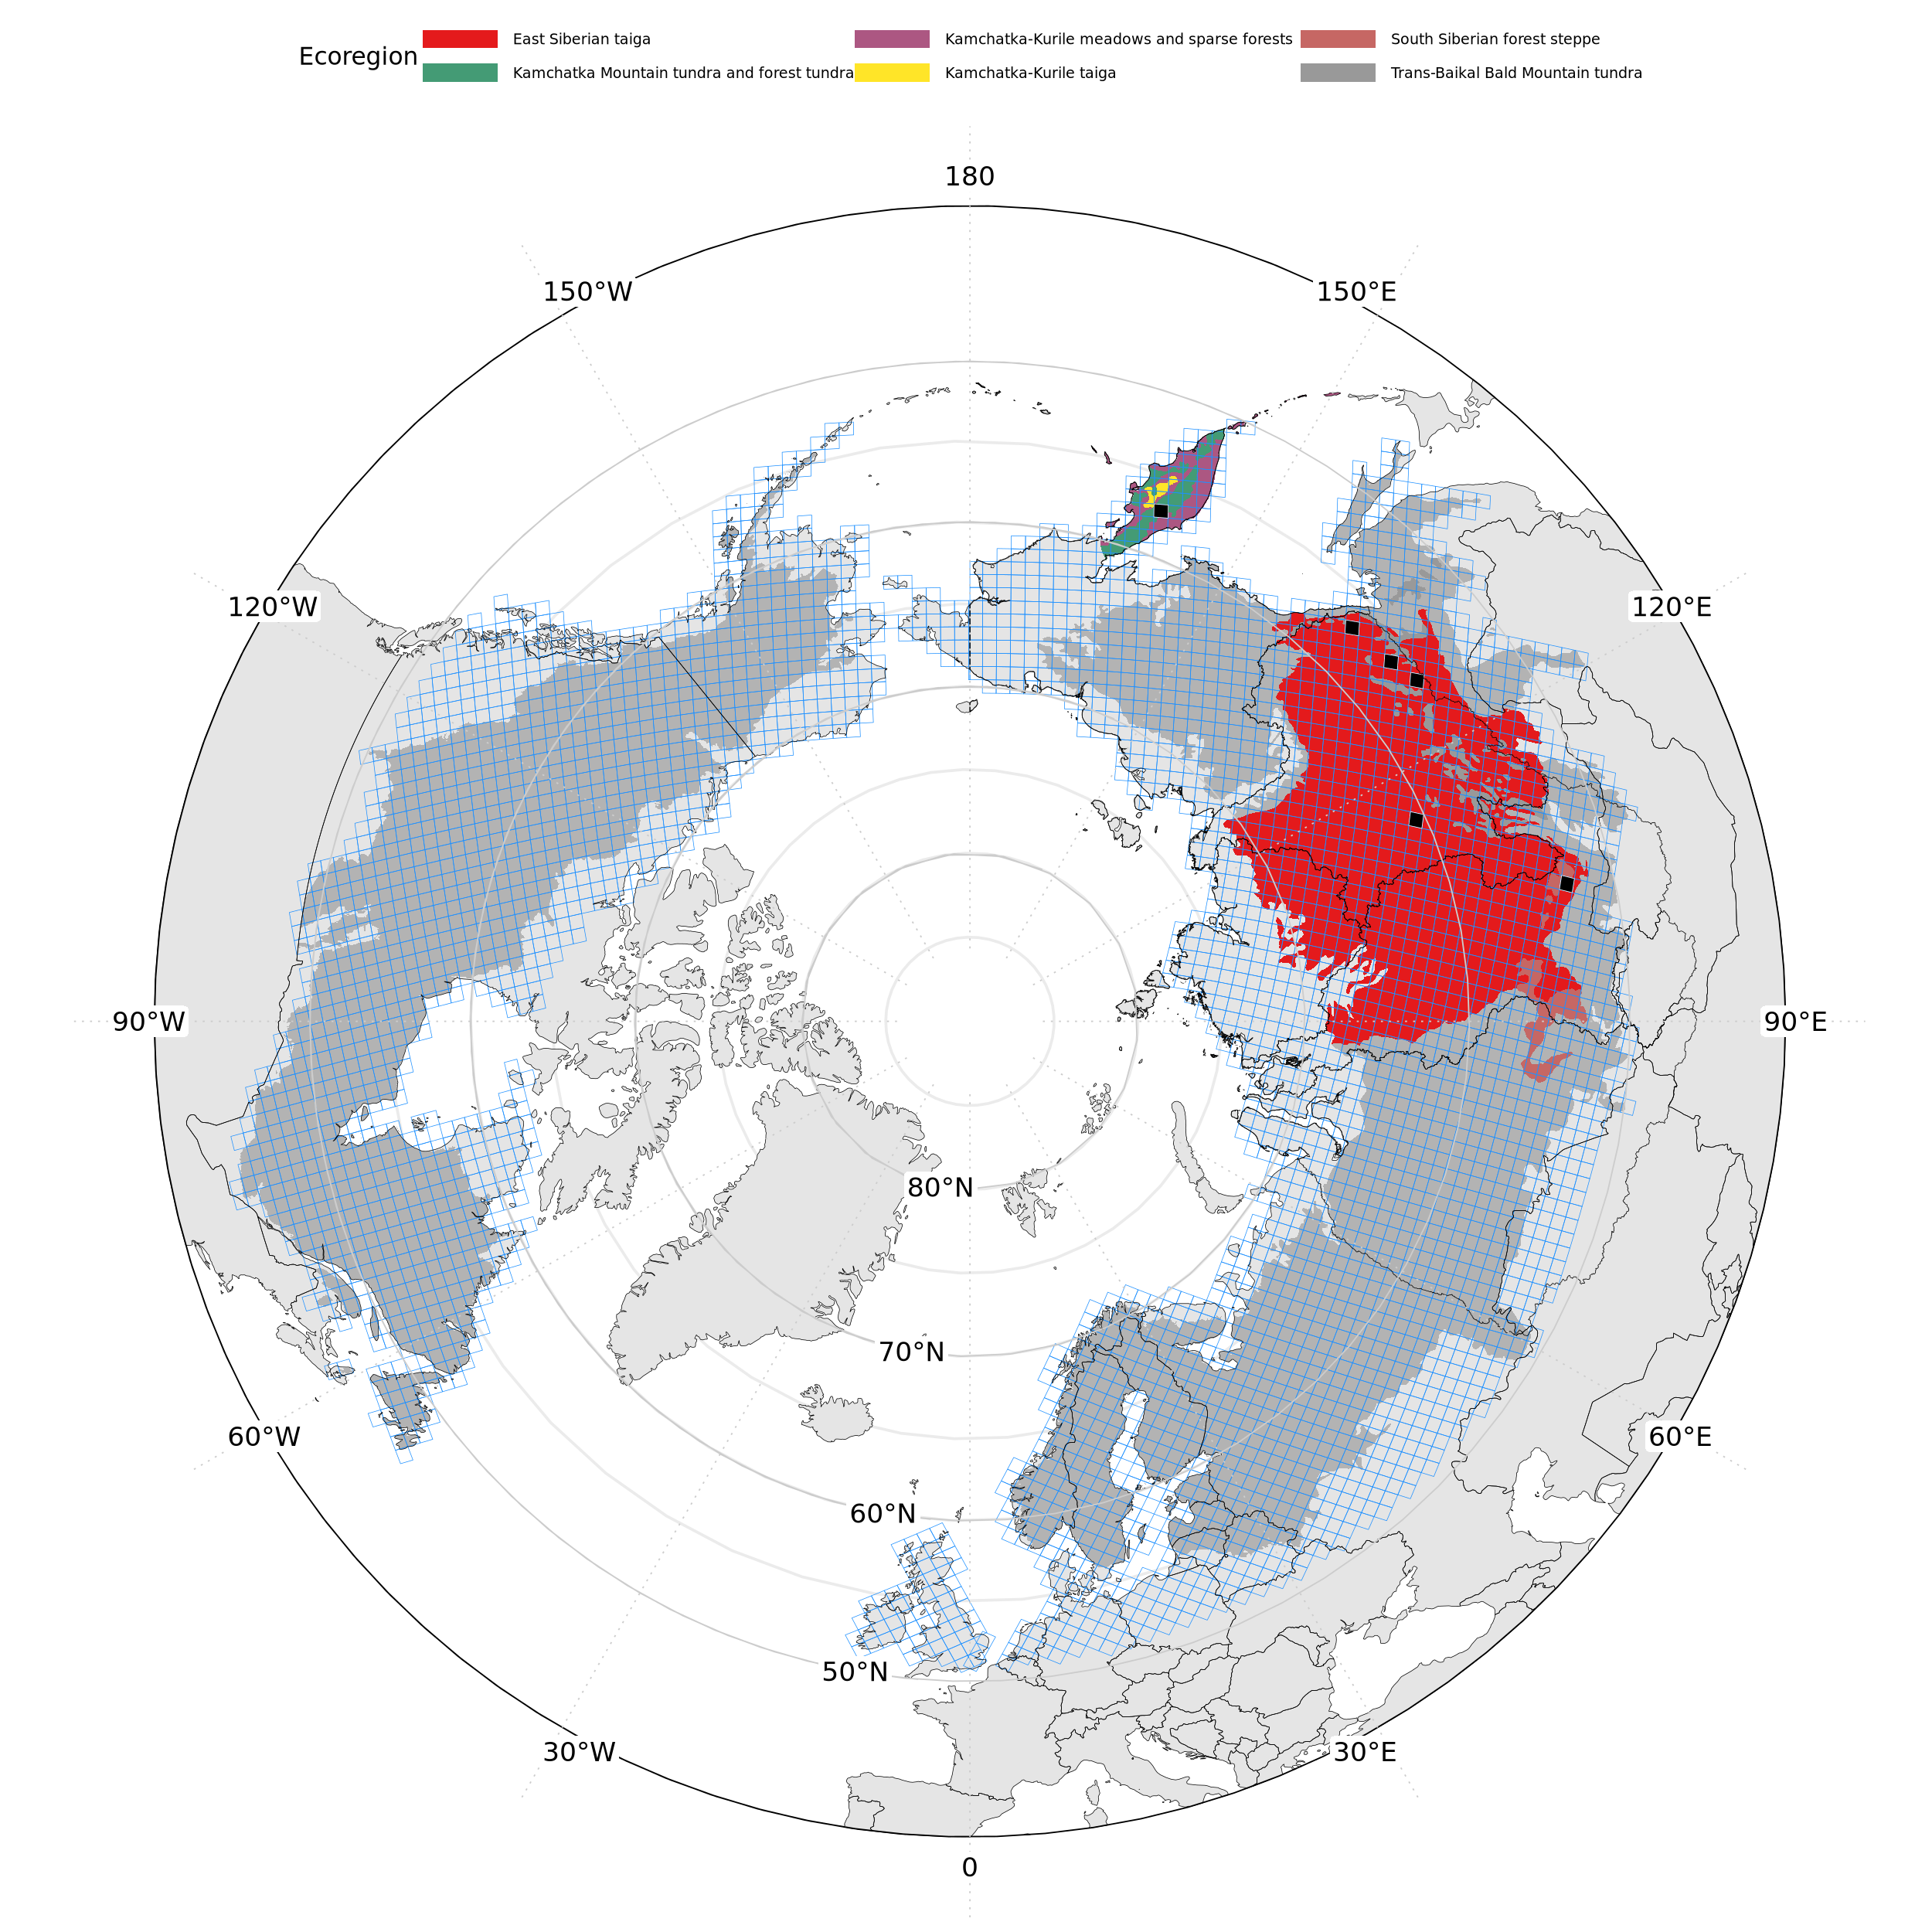

In [28]:
options(repr.plot.width = 10, repr.plot.height = 10, repr.plot.res = 250)

colourCount = length(unique(wwf_ecoregions$ecoregions_ECO_NAME))
print(paste0("Cluster count is: ",colourCount))
getPalette = colorRampPalette(brewer.pal(9, "Set1"))


ecoregion_colors <-getPalette(colourCount)
names(ecoregion_colors) <- levels(factor(wwf_ecoregions$ecoregions_ECO_NAME))

m_boreal_tiles = DO_MAP_BOREAL_SP(MAP_EXTENT=ext,  
                     BOREAL_SHP_FN = wwf_circ_dis_fn,
                     LAYER_LIST = list(
                         geom_polygon(data = wwf_ecoregions, aes(x = long, y = lat, group = group, fill=ecoregions_ECO_NAME), size=0.1),
                         scale_fill_grey(start = 0.25, end = 0, name=NULL), # the dark end
                         scale_fill_manual(values = ecoregion_colors, name="Ecoregion"),
                         geom_polygon(data = boreal_tiles_DAAC_gcs, aes(x = long, y = lat, group = group), size=0.1, fill=NA, color='dodgerblue'),
                         geom_polygon(data = boreal_tiles_DAAC_gcs %>% filter(tile_num %in% TILE_NUM_LIST), aes(x = long, y = lat, group = group), size=0.1, fill='black', color='white'),
                         geom_polygon(data = hydrobasin_si_lev02, aes(x = long, y = lat, group = group), size=0.1, fill=NA, color='black') 
                         #,
                         #, geom_text(data = boreal_tiles_DAAC_gcs %>% filter(tile_num %in% TILE_NUM_LIST) %>% group_by(tile_num) %>%
                         #      summarize(long = mean(long),
                         #                lat = mean(lat)),
                         #      aes(x = long, y = lat, label = tile_num), size = 2.5, fontface = "bold")
                     ) #, fill=NA
                    ) + 
    theme(legend.text=element_text(size=rel(0.5)))
m_boreal_tiles

### Various totals  
C totals for ecoregion needs to come from from all the `summary_df` data frames - not yet ready



In [29]:
# Just to check total
totals_ecoregion = summary_df %>% group_by(ecoregions_ECO_NAME) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
totals_tile = summary_df %>% group_by(ID) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
totals_decid = summary_df %>% group_by(deciduous_class) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
totals_tile_decid = summary_df %>% group_by(ecoregions_ECO_NAME, ID, deciduous_class) %>% summarize(Total_C = sum(total_carbon_Pg),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                       )
fraction_ecoregion_age = summary_df %>% 
    #drop_na() %>% 
    group_by(ecoregions_ECO_NAME, age_cohort) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_tile_age = summary_df %>% 
    #drop_na() %>% 
    group_by(ID, age_cohort) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_age_decid = summary_df %>% 
    #drop_na() %>% 
    group_by(deciduous_class, age_cohort) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_ecoregion_trend = summary_df %>% 
    group_by(ecoregions_ECO_NAME, trend_class) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
fraction_tile_trend = summary_df %>% 
    group_by(ID, trend_class) %>% 
    summarize(
        Total_C = sum(total_carbon_Pg), 
        Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
        Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
    )
# ---wont work - b/c fraction calc'd sin smry by tile
# fraction_trend_decid = summary_df %>% 
#     group_by(trend_class, deciduous_class) %>% 
#     summarize(
#         Total_C = sum(total_carbon_Pg), 
#         Fraction_area = sum(fractional_area), Percent_area_round = 100 * round(sum(fractional_area), dig=3),
#         Fraction_C = sum(fractional_C), Percent_C_round = 100 * round(sum(fractional_C), dig=3)
#     )

`summarise()` has grouped output by 'ecoregions_ECO_NAME', 'ID'. You can
override using the `.groups` argument.
`summarise()` has grouped output by 'ecoregions_ECO_NAME'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'ID'. You can override using the `.groups`
argument.
`summarise()` has grouped output by 'deciduous_class'. You can override using
the `.groups` argument.
`summarise()` has grouped output by 'ecoregions_ECO_NAME'. You can override
using the `.groups` argument.
`summarise()` has grouped output by 'ID'. You can override using the `.groups`
argument.


#### Ecoregion total donut plot

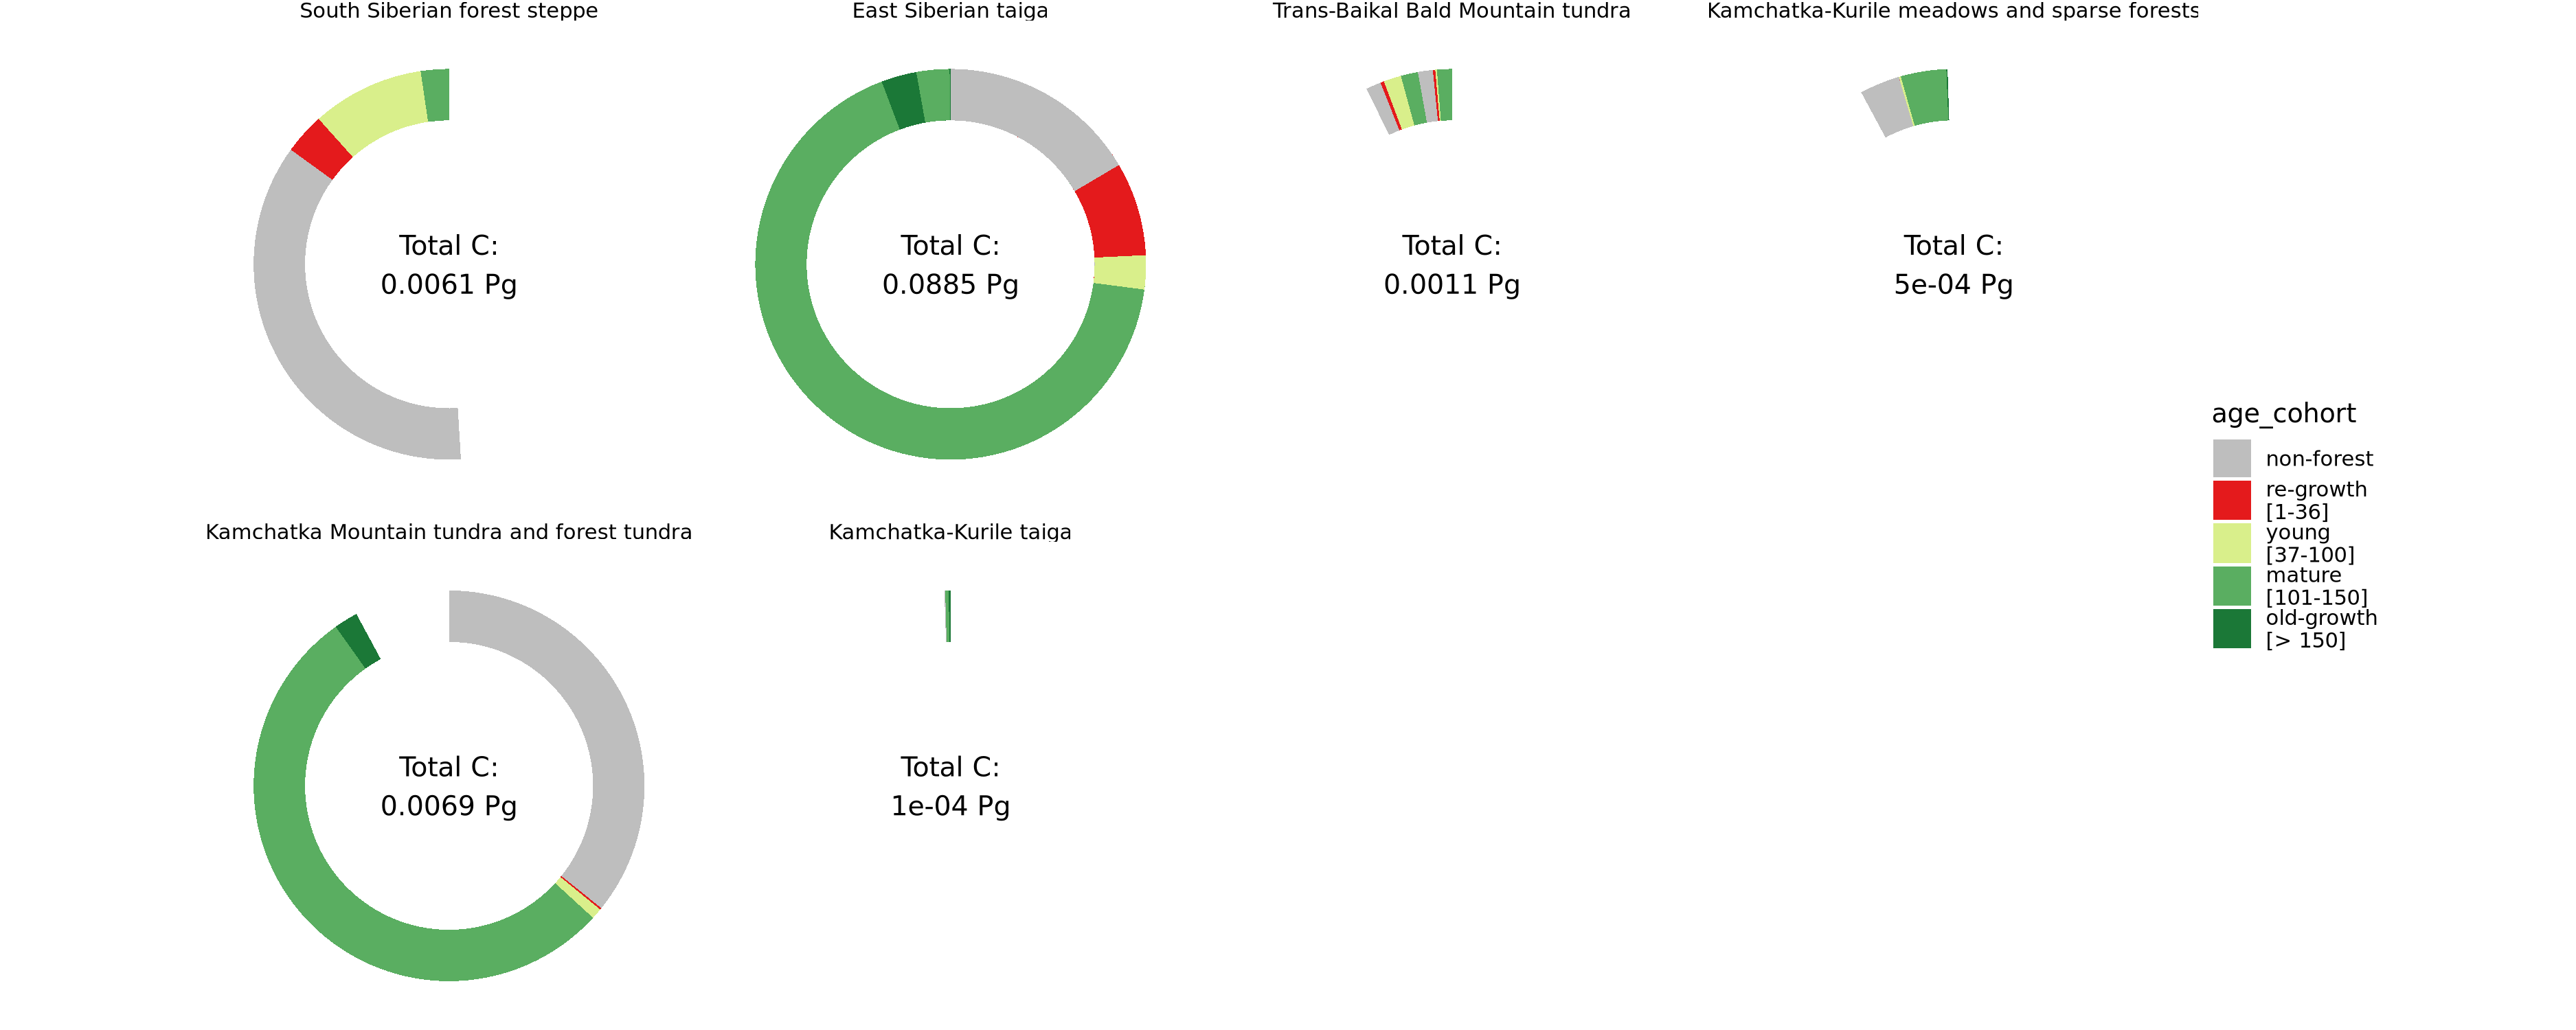

In [31]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 250)

ggplot() +
    geom_rect(summary_df, mapping=aes(ymax=ymax, ymin=ymin, xmax=4, xmin=3, fill=age_cohort)) + 
    scale_fill_manual(values=age_colors) +
    coord_polar(theta = "y", start = 0) +
    #xlim(c(1, 4)) +
    # Add center annotation showing total carbon
      # geom_text(aes(
      #   x = 0.2,  # Position text in center
      #   y = 0,    # Any value works as we're not using this dimension
      #   label = paste0("Total C:\n", round(sum(total_carbon_Pg), 7), " Pg")
      #     ), size = 4) +
      geom_text(data=totals_ecoregion, mapping=aes(
        x = 0.2,  # Position text in center
        y = 0,    # Any value works as we're not using this dimension
        label = paste0("Total C:\n", round(Total_C, 4), " Pg")
          ), size = 4) +
    theme_void() +
    facet_wrap(~ecoregions_ECO_NAME, ncol=4)

### Bars plot of C (Total & Density) by Age Cohort - CHECK

**CHECK:**  
check these summaries against the pixel_df version of the results - b/c the `C density [Mg/ha]` version of the plots doesnt make sense (too high?)


In [32]:
text_total_C = list(
        geom_text(data=totals_tile, mapping=aes(
            x = 0,  # Position text in center
            y = Inf,    # Any value works as we're not using this dimension
            label = paste0(round(Total_C, 4), " Pg C")
              ), size = 4, hjust=-0.05, vjust=1.5)
    )
text_total_C_ecoregion = list(
        geom_text(data=totals_ecoregion, mapping=aes(
            x = 0,  # Position text in center
            y = Inf,    # Any value works as we're not using this dimension
            label = paste0(round(Total_C, 4), " Pg C")
              ), size = 4, hjust=-0.05, vjust=1.5)
    )

text_total_C_decid = list(
        geom_text(data=totals_decid, mapping=aes(
            x = 0,  # Position text in center
            y = Inf,    # Any value works as we're not using this dimension
            label = paste0(round(Total_C, 4), " Pg C")
              ), size = 4, hjust=-0.05, vjust=1.5)
    )
text_total_C_tile_decid = list(
        geom_text(data=totals_tile_decid, mapping=aes(
            x = 0,  # Position text in center
            y = Inf,    # Any value works as we're not using this dimension
            label = paste0(round(Total_C, 4), " Pg C")
              ), size = 4, hjust=-0.05, vjust=1.5)
    )

In [33]:
summary_df$total_carbon_Pg_chk = summary_df$total_carbon_Pg - summary_df$total_carbon_Pg_mean

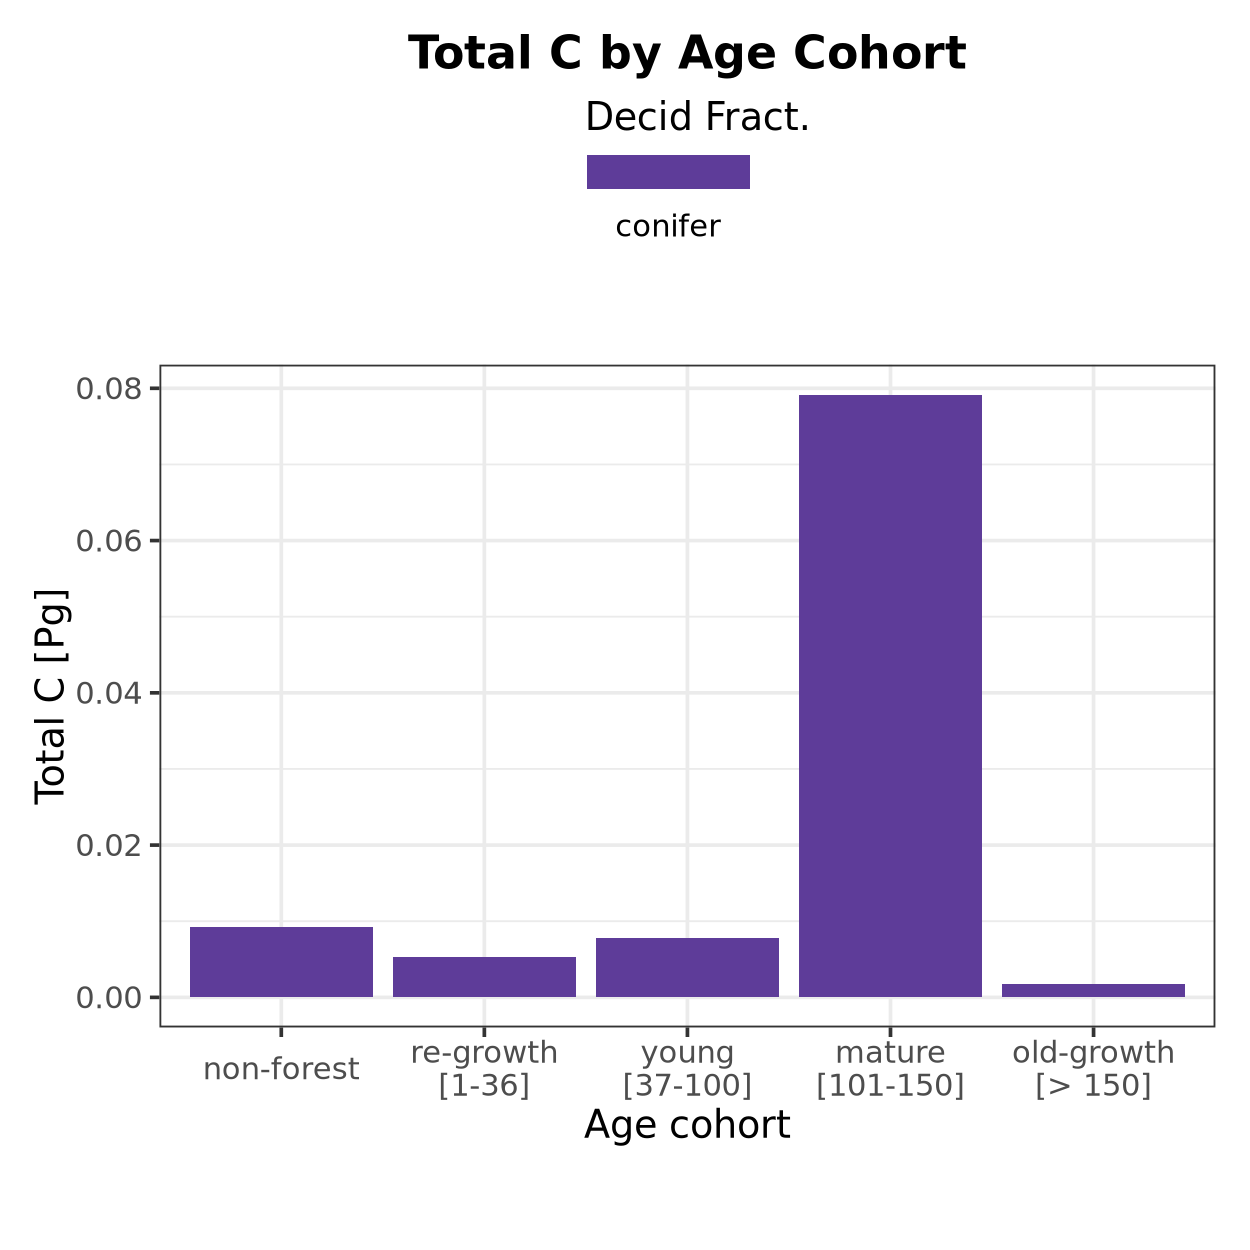

In [34]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 250)
geom_list_theme = list(
                    theme_bw() ,
                theme(axis.text.x = element_blank()) ,
                theme(
                    #axis.text.x = element_text(angle=90),
                    legend.position = "top",
                    #legend.text = element_text(angle = 90, hjust = 1),
                    legend.spacing.x = unit(0.4, "cm"),
                    legend.margin = margin(t = 0, r = 0, b = 25, l = 0), # Add space for rotated text
                    plot.margin = margin(b = 30, t = 10, l = 10, r = 10),
                    plot.title = element_text(hjust = 0.5, face = "bold")
              ) 
    )
geom_list_bars_age = list(
            scale_fill_manual(values=age_colors, #name='Age cohort'
                                 guide = guide_legend(
                  direction = "horizontal",
                  title = 'Age cohort (forest demography)',
                  title.position = "top",
                  label.position = "bottom",
                  label.hjust = 0.5,
                  label.vjust = 0.5,
                  keywidth = unit(1.7, "cm"),
                  keyheight = unit(0.4, "cm"),
                  nrow = 1
                        )
                ),
            geom_list_theme
            )
geom_list_bars_decid = list(
            scale_fill_manual(values=colors_decidpred,
                                 guide = guide_legend(
                  direction = "horizontal",
                  title = 'Decid Fract.',
                  title.position = "top",
                  label.position = "bottom",
                  label.hjust = 0.5,
                  label.vjust = 0.5,
                  keywidth = unit(1.7, "cm"),
                  keyheight = unit(0.4, "cm"),
                  nrow = 1
                        )
                ),
            geom_list_theme
            )
p_bars_age_decid = ggplot() +
    geom_bar(summary_df , mapping=aes( x=age_cohort, y=total_carbon_Pg, fill=deciduous_class) , stat='identity') + # for a regular bar plot - fast
    geom_list_bars_decid +
    #ylim(c(0,0.006)) +
    #facet_grid(deciduous_class~ ID) + 
    #geom_errorbar(data=totals_tile_age, mapping=aes( x=age_cohort, ymin=Total_C_pi_lwr, ymax=Total_C_pi_upr, group=age_cohort)) +
    #text_total_C_tile_decid +
    #geom_text(data=fraction_age_decid, mapping=aes(x=age_cohort, y=Total_C, label=paste0(Percent_C_round,'%\n(',Percent_area_round,'%)')), size=2, vjust=-1) +
    labs(y='Total C [Pg]', x='Age cohort', title='Total C by Age Cohort') +
theme(axis.text.x = element_text(angle=0))
p_bars_age_decid


Warning message:
“Removed 45 rows containing missing values or values outside the scale range
(`geom_bar()`).”


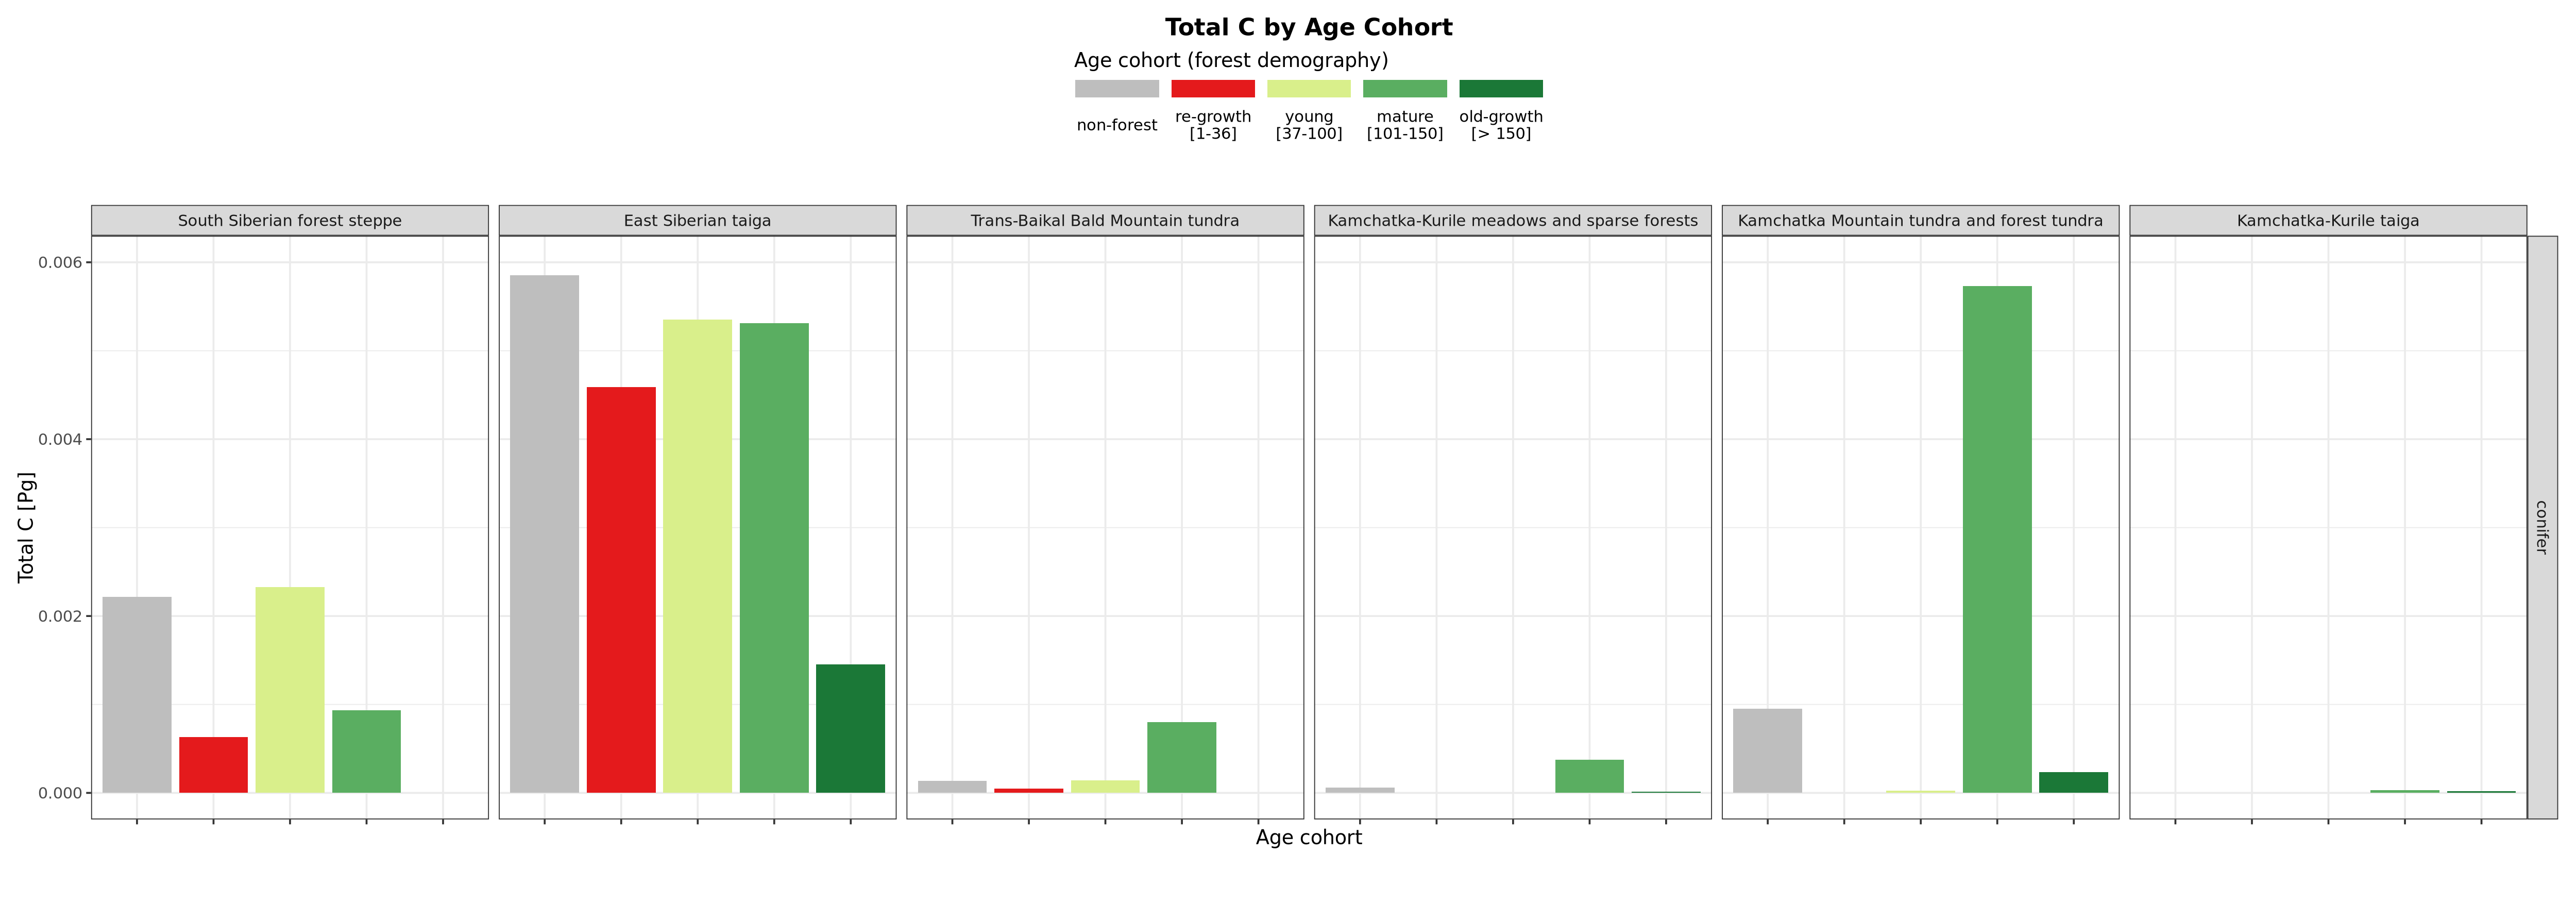

In [35]:
options(repr.plot.width = 20, repr.plot.height = 7, repr.plot.res = 250)
p_bars_decid_age = ggplot() +
    geom_bar(summary_df , mapping=aes( x=age_cohort, y=total_carbon_Pg, fill=age_cohort) , stat='identity') + # for a regular bar plot - fast
    geom_list_bars_age +
    ylim(c(0,0.006)) +
    facet_grid(deciduous_class~ ecoregions_ECO_NAME) + 
    #geom_errorbar(data=totals_tile_age, mapping=aes( x=age_cohort, ymin=Total_C_pi_lwr, ymax=Total_C_pi_upr, group=age_cohort)) +
    #text_total_C_tile_decid +
    #geom_text(data=fraction_age_decid, mapping=aes(x=age_cohort, y=Total_C, label=paste0(Percent_C_round,'%\n(',Percent_area_round,'%)')), size=2, vjust=-1) +
    labs(y='Total C [Pg]', x='Age cohort', title='Total C by Age Cohort')
p_bars_decid_age

###### note: fix `fraction_ecoregion_age` by pulling fraction calc out from tile-level df and doing it based on ecoregion after summary_df_list has been combined

`summarise()` has grouped output by 'ecoregions_ECO_NAME'. You can override
using the `.groups` argument.
Warning message:
“Removed 47 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_text()`).”


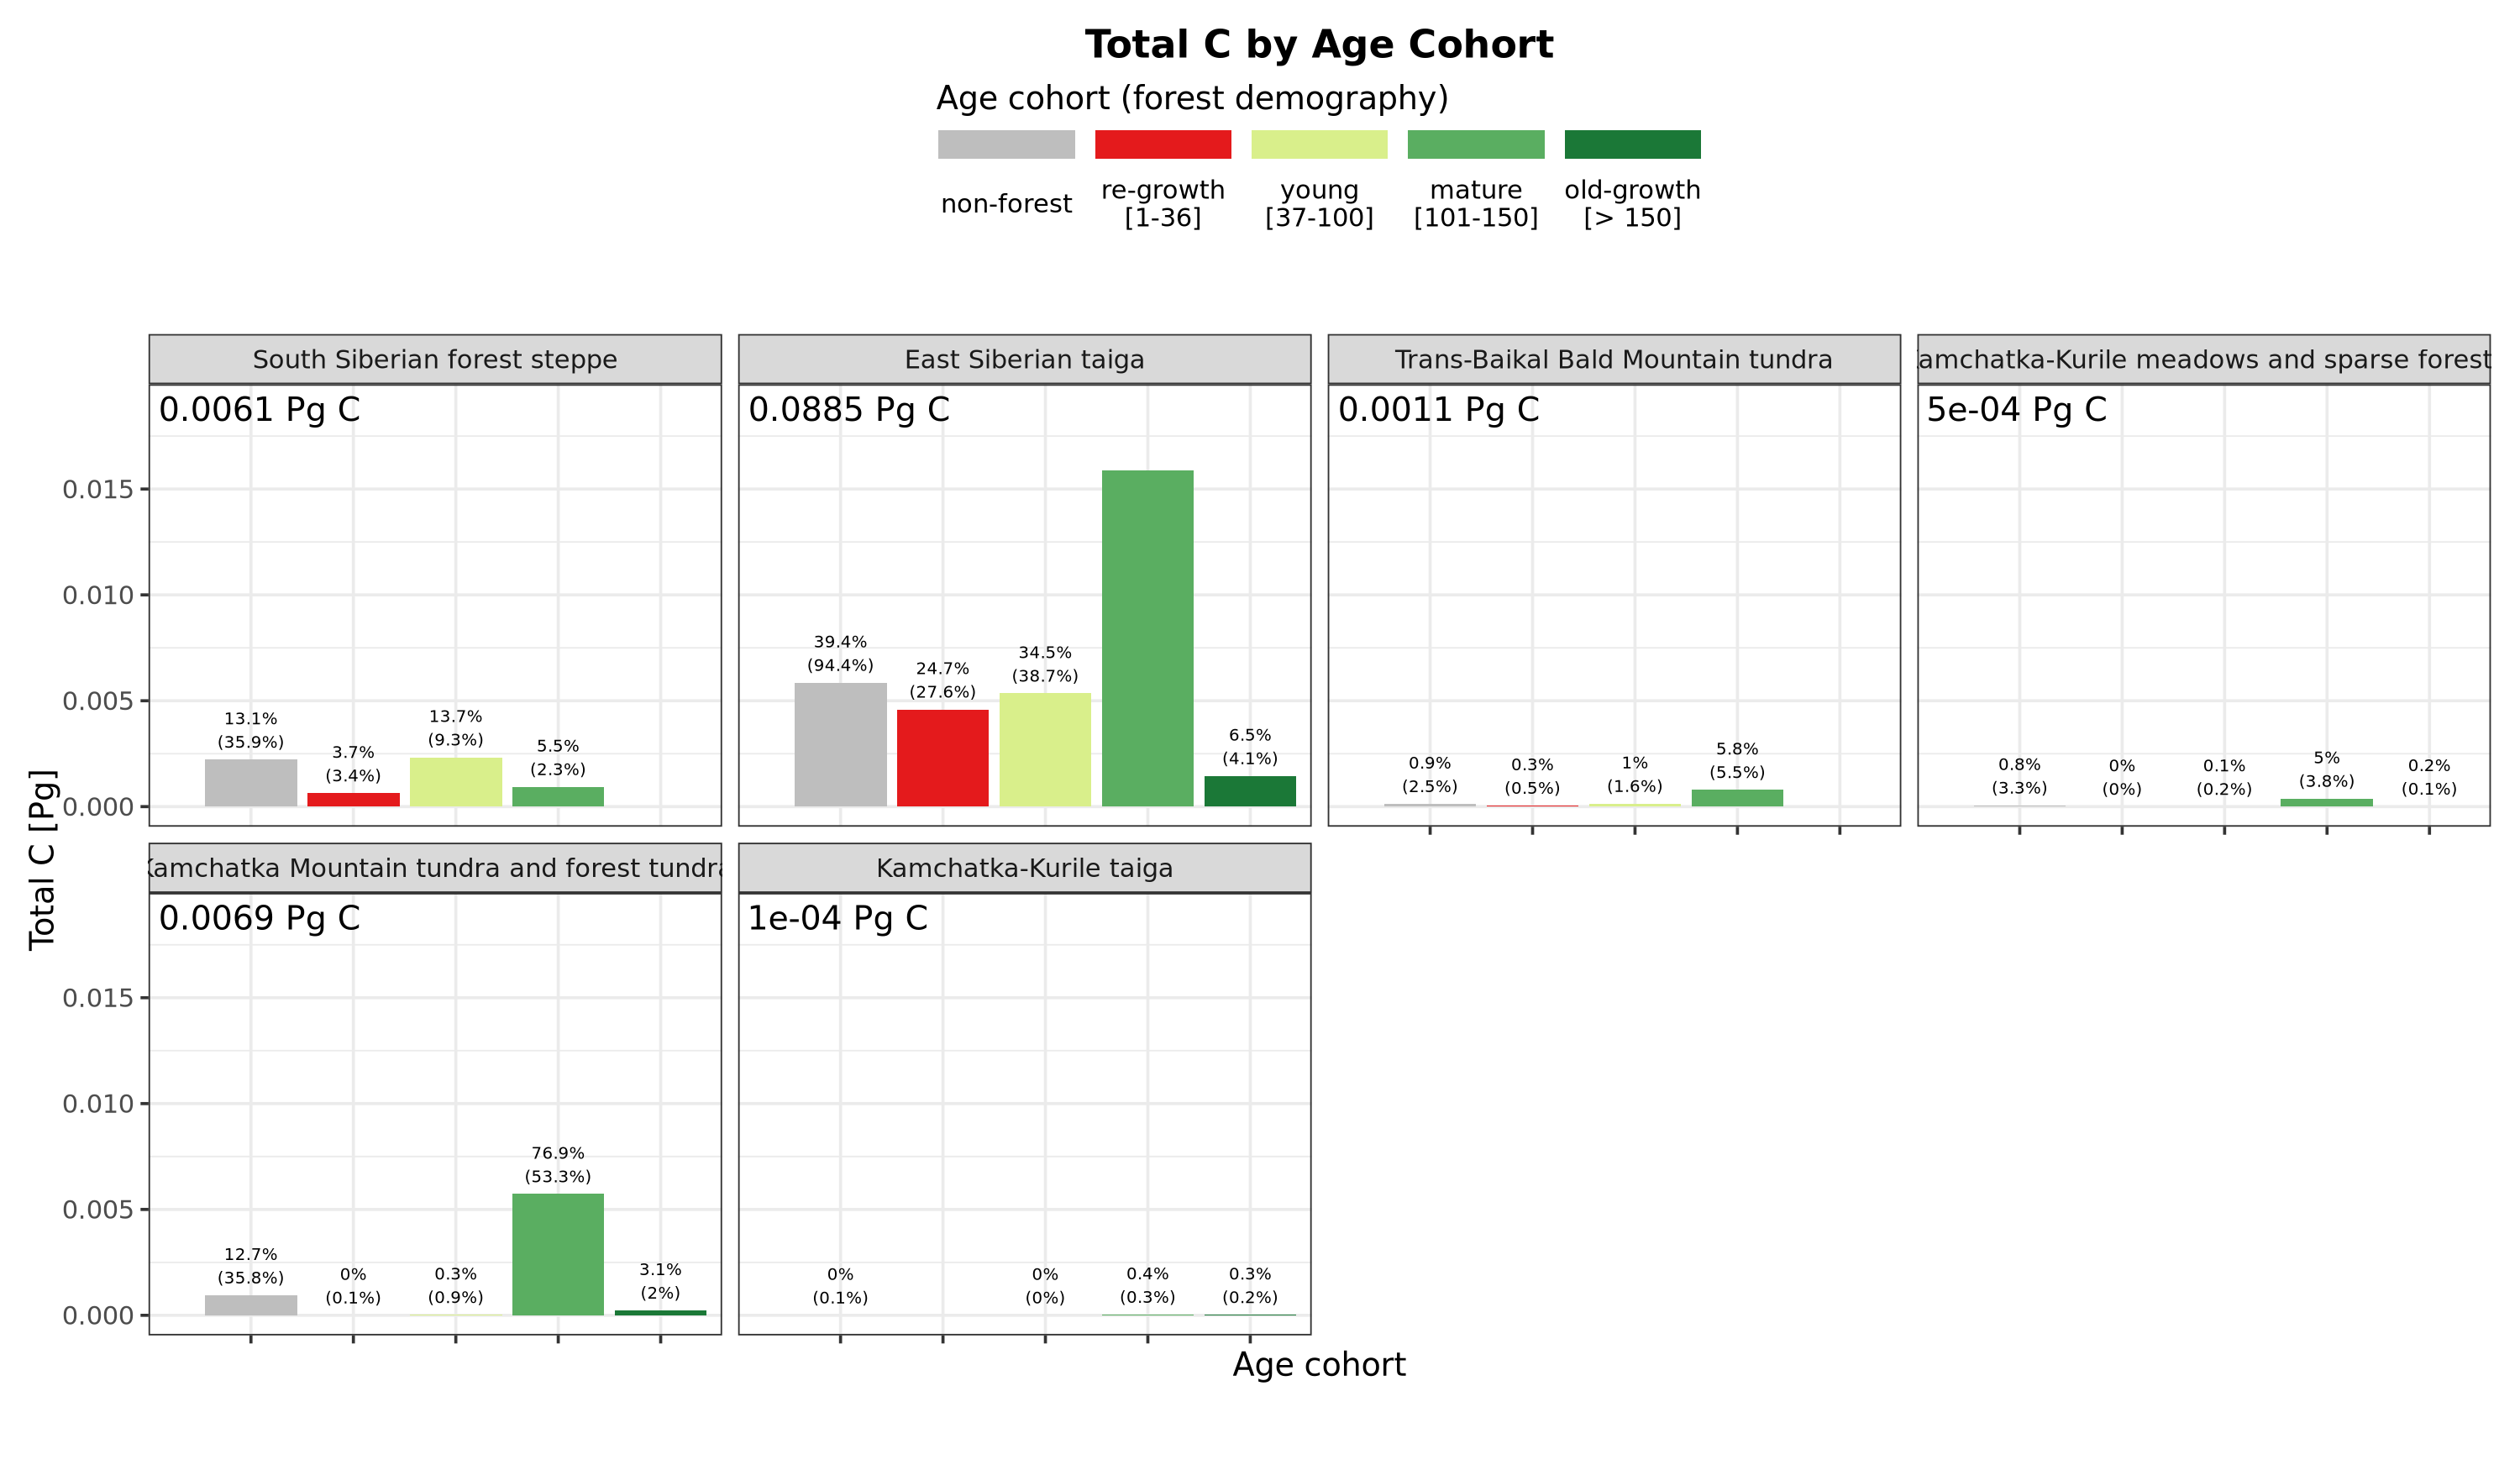

In [36]:
options(repr.plot.width = 12, repr.plot.height = 7, repr.plot.res = 250)

totals_ecoregion_age = summary_df %>% 
                        drop_na() %>% 
                        group_by(ecoregions_ECO_NAME, age_cohort) %>% 
                        summarize(Total_C = sum(total_carbon_Pg_mean),
                                                       Total_C_ci_lwr = sum(total_carbon_Pg_ci_lower),
                                                       Total_C_ci_upr = sum(total_carbon_Pg_ci_upper),
                                                        Total_C_pi_lwr = sum(total_carbon_Pg_pi_lower),
                                                       Total_C_pi_upr = sum(total_carbon_Pg_pi_upper),
                                  Total_area_ha = sum(area_ha)
                                                       )

p_bars_age = ggplot() +
    geom_bar(summary_df , mapping=aes( x=age_cohort, y=total_carbon_Pg, fill=age_cohort) , stat='identity') + # for a regular bar plot - fast
    geom_list_bars_age +
    ylim(c(0,0.019)) +
    facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) + 
    #geom_errorbar(data=totals_tile_age, mapping=aes( x=age_cohort, ymin=Total_C_pi_lwr, ymax=Total_C_pi_upr, group=age_cohort)) +
    text_total_C_ecoregion +
    geom_text(data=fraction_ecoregion_age, mapping=aes(x=age_cohort, y=Total_C, label=paste0(Percent_C_round,'%')), size=2, vjust=-3) +
    geom_text(data=fraction_ecoregion_age, mapping=aes(x=age_cohort, y=Total_C, label=paste0('(',Percent_area_round,'%)')), size=2, vjust=-1) +

    labs(y='Total C [Pg]', x='Age cohort', title='Total C by Age Cohort')
p_bars_age

# _ something is wrong with the conversion here _
# p_bars_age_area = ggplot() +
#     geom_bar(summary_df , mapping=aes( x=age_cohort, y=(total_carbon_Pg*10**9)/area_ha, fill=age_cohort) , stat='identity') + # for a regular bar plot - fast
#     geom_list_bars_age +
#     facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) + 
#     #geom_errorbar(data=totals_tile_age, mapping=aes( x=age_cohort, ymin=Total_C_pi_lwr, ymax=Total_C_pi_upr, group=age_cohort)) +
#     text_total_C +
#     geom_text(data=fraction_tile_age, mapping=aes(x=age_cohort, y=Total_C, label=paste0(Percent_C_round,'%')), size=2, vjust=-1) +
#     labs(y='C density [Mg/ha]', x='Age cohort', title='C density by Age Cohort')
# p_bars_age_area

In [37]:
guide = guide_legend(
      direction = "horizontal",
      title = NULL,
      label.position = "bottom",
      label.hjust = 0.5,
      label.vjust = 0.5,
      keywidth = unit(1.2, "cm"),
      keyheight = unit(0.8, "cm"),
      nrow = 1
    )

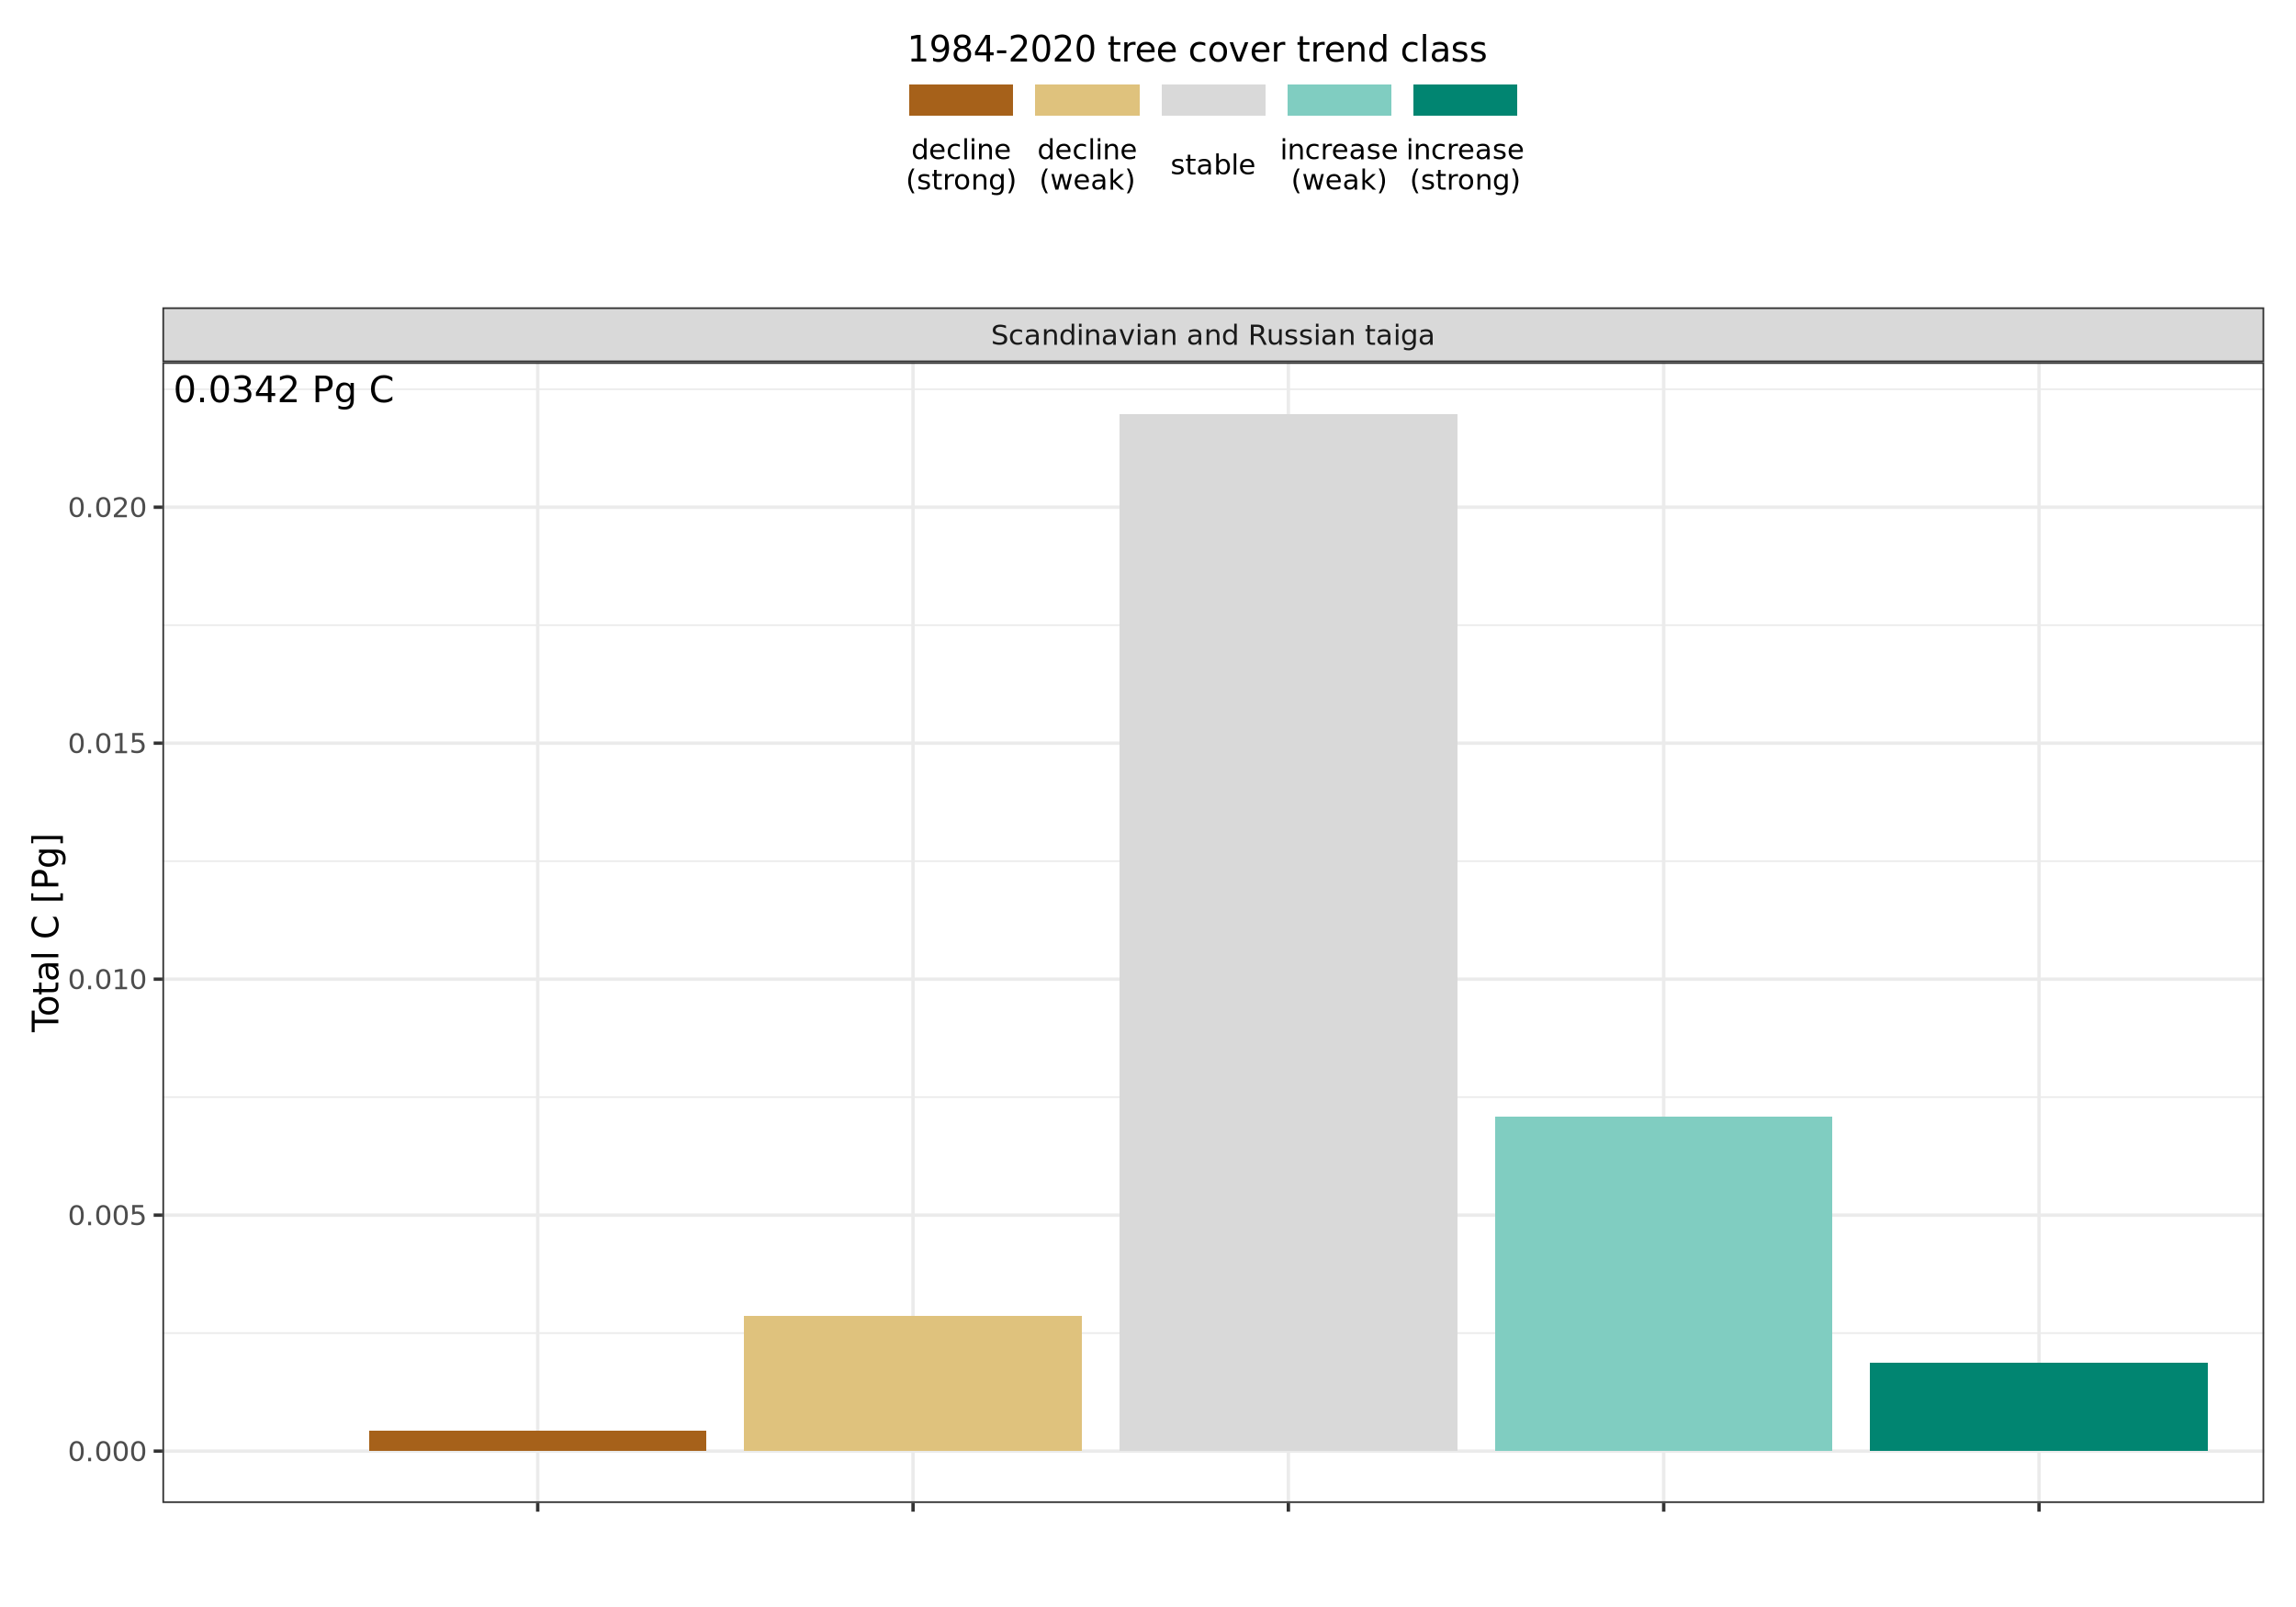

In [39]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 250)

geom_list_bars_trend = list(
    scale_fill_manual(values=trend_colors, #name='1984-2020\ntree cover\ntrend class', 
                         guide = guide_legend(
          direction = "horizontal",
          title = '1984-2020 tree cover trend class',
          title.position = "top",
          label.position = "bottom",
          label.hjust = 0.5,
          label.vjust = 0.5,
          keywidth = unit(1.2, "cm"),
          keyheight = unit(0.4, "cm"),
          nrow = 1
            )
    ),
    theme(
        axis.text.x = element_blank(),
        legend.position = "top",
        #legend.text = element_text(angle = 90, hjust = 1),
        legend.spacing.x = unit(0.4, "cm"),
        legend.margin = margin(t = 0, r = 0, b = 25, l = 0), # Add space for rotated text
        plot.margin = margin(b = 30, t = 10, l = 10, r = 10),
        plot.title = element_text(hjust = 0.5, face = "bold")
      ) 
    )
p_bars_trend = ggplot() +
    geom_bar(summary_df , mapping=aes( x=trend_class, y=total_carbon_Pg, fill=trend_class) , stat='identity') + # for a regular bar plot - fast
    facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) + 
    text_total_C_ecoregion + 
    theme_bw() +
    #geom_text(data=fraction_tile_trend, mapping=aes(x=trend_class, y=Total_C, label=paste0(Percent_C_round,'%')), size=2, vjust=-1) +
    #theme(axis.text.x = element_blank()) +
    geom_list_bars_trend +
    labs(y='Total C [Pg]', x=NULL)
p_bars_trend

In [287]:
# options(repr.plot.width = 10, repr.plot.height = 15, repr.plot.res = 250)

# p_bars_trend_decid = ggplot() +
#     geom_bar(summary_df , mapping=aes( x=trend_class, y=total_carbon_Pg, fill=trend_class) , stat='identity') + # for a regular bar plot - fast
#     facet_grid(ecoregions_ECO_NAME~ deciduous_class) + 
#     #text_total_C_decid + 
#     theme_bw() +
#     #geom_text(data=fraction_trend_decid, mapping=aes(x=trend_class, y=Total_C, label=paste0(Percent_C_round,'%')), size=2, vjust=-1) +
#     #theme(axis.text.x = element_blank()) +
#     geom_list_bars_trend +
#     labs(y='Total C [Pg]', x='1984-2020 tree cover trend class')
# p_bars_trend_decid

### Bars plot of Total C by Age Cohort and by Trend Class

In [288]:
levels(summary_df$ecoregions_ECO_NAME)

[1] "Southern Hudson Bay taiga"                       
 [2] "Central Canadian Shield forests"                 
 [3] "Torngat Mountain tundra"                         
 [4] "Eastern Canadian Shield taiga"                   
 [5] "Newfoundland Highland forests"                   
 [6] "Eastern Canadian forests"                        
 [7] "Scandinavian Montane Birch forest and grasslands"
 [8] "Scandinavian and Russian taiga"                  
 [9] "Kola Peninsula tundra"                           
[10] "Ural montane forests and tundra"                 
[11] "West Siberian taiga"                             
[12] "East Siberian taiga"                             
[13] "Northeast Siberian taiga"

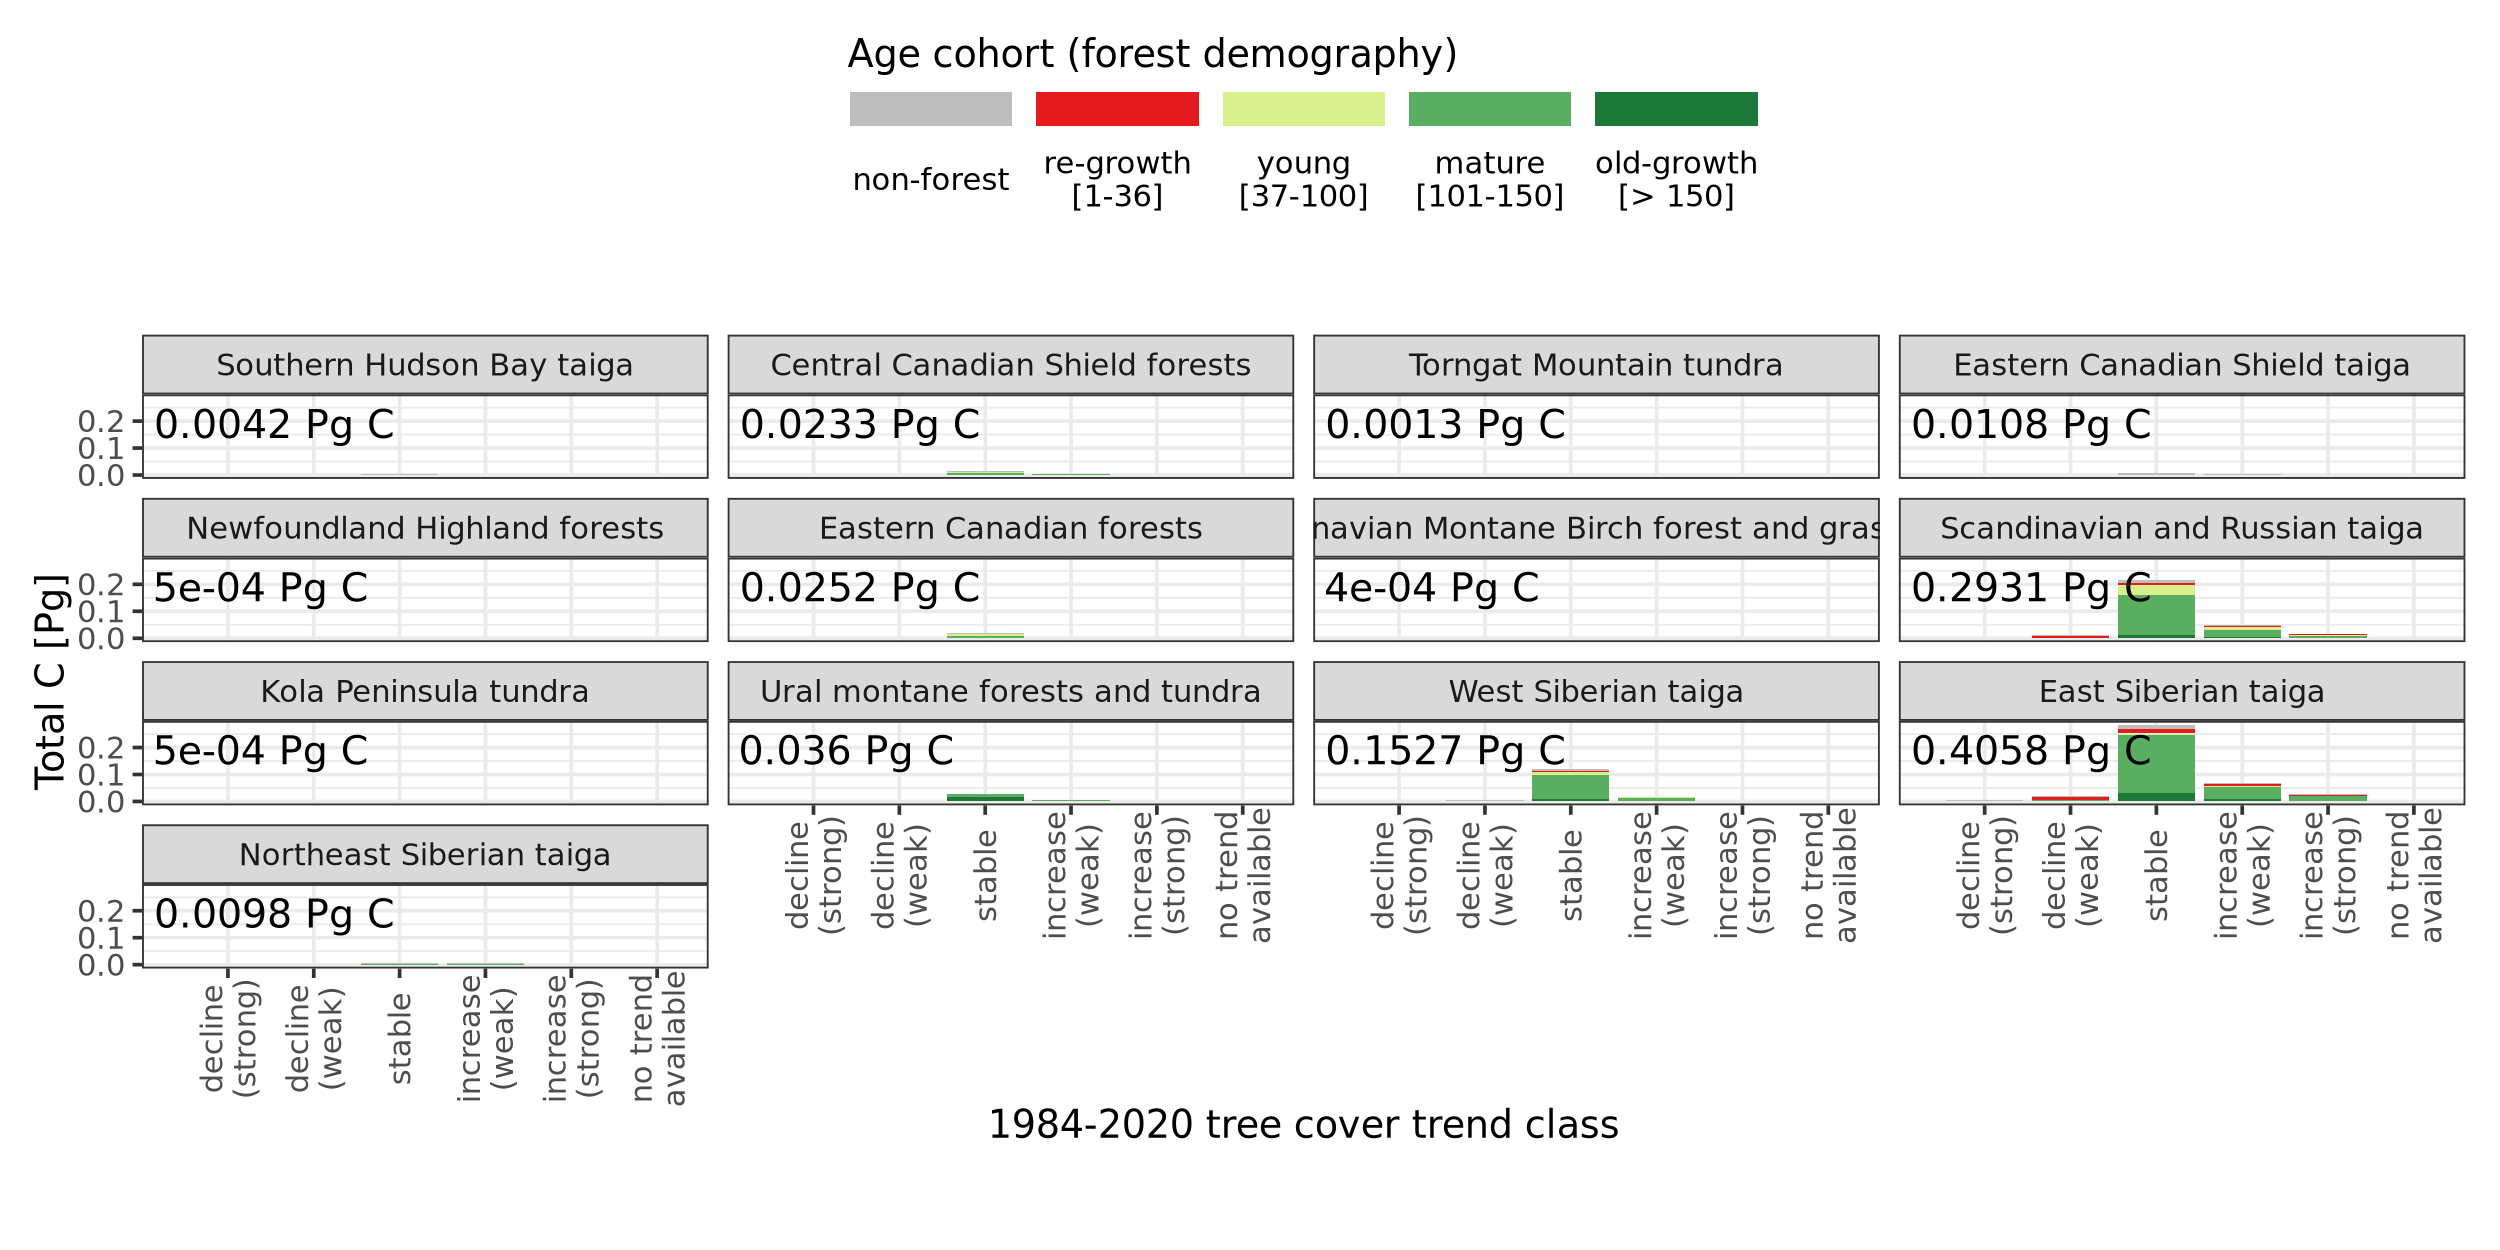

In [289]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 250)

p_bars_age_trend = ggplot( ) +
    geom_bar(summary_df , mapping = aes( x=trend_class, y=total_carbon_Pg, fill=age_cohort), stat='identity') + # for a regular bar plot - fast 
    text_total_C_ecoregion +
    facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) + 
    theme_bw() +
    geom_list_bars_age +
    theme(axis.text.x = element_text(angle=90)) +
    labs(y='Total C [Pg]', x='1984-2020 tree cover trend class')
p_bars_age_trend

In [290]:
pvalue_class_alpha = c(0.1, 0.25, 1)
names(pvalue_class_alpha) = levels(factor(summary_df$pvalue_class))
pvalue_class_alpha

no trend\navailable             not sig        sig (p<0.05) 
               0.10                0.25                1.00

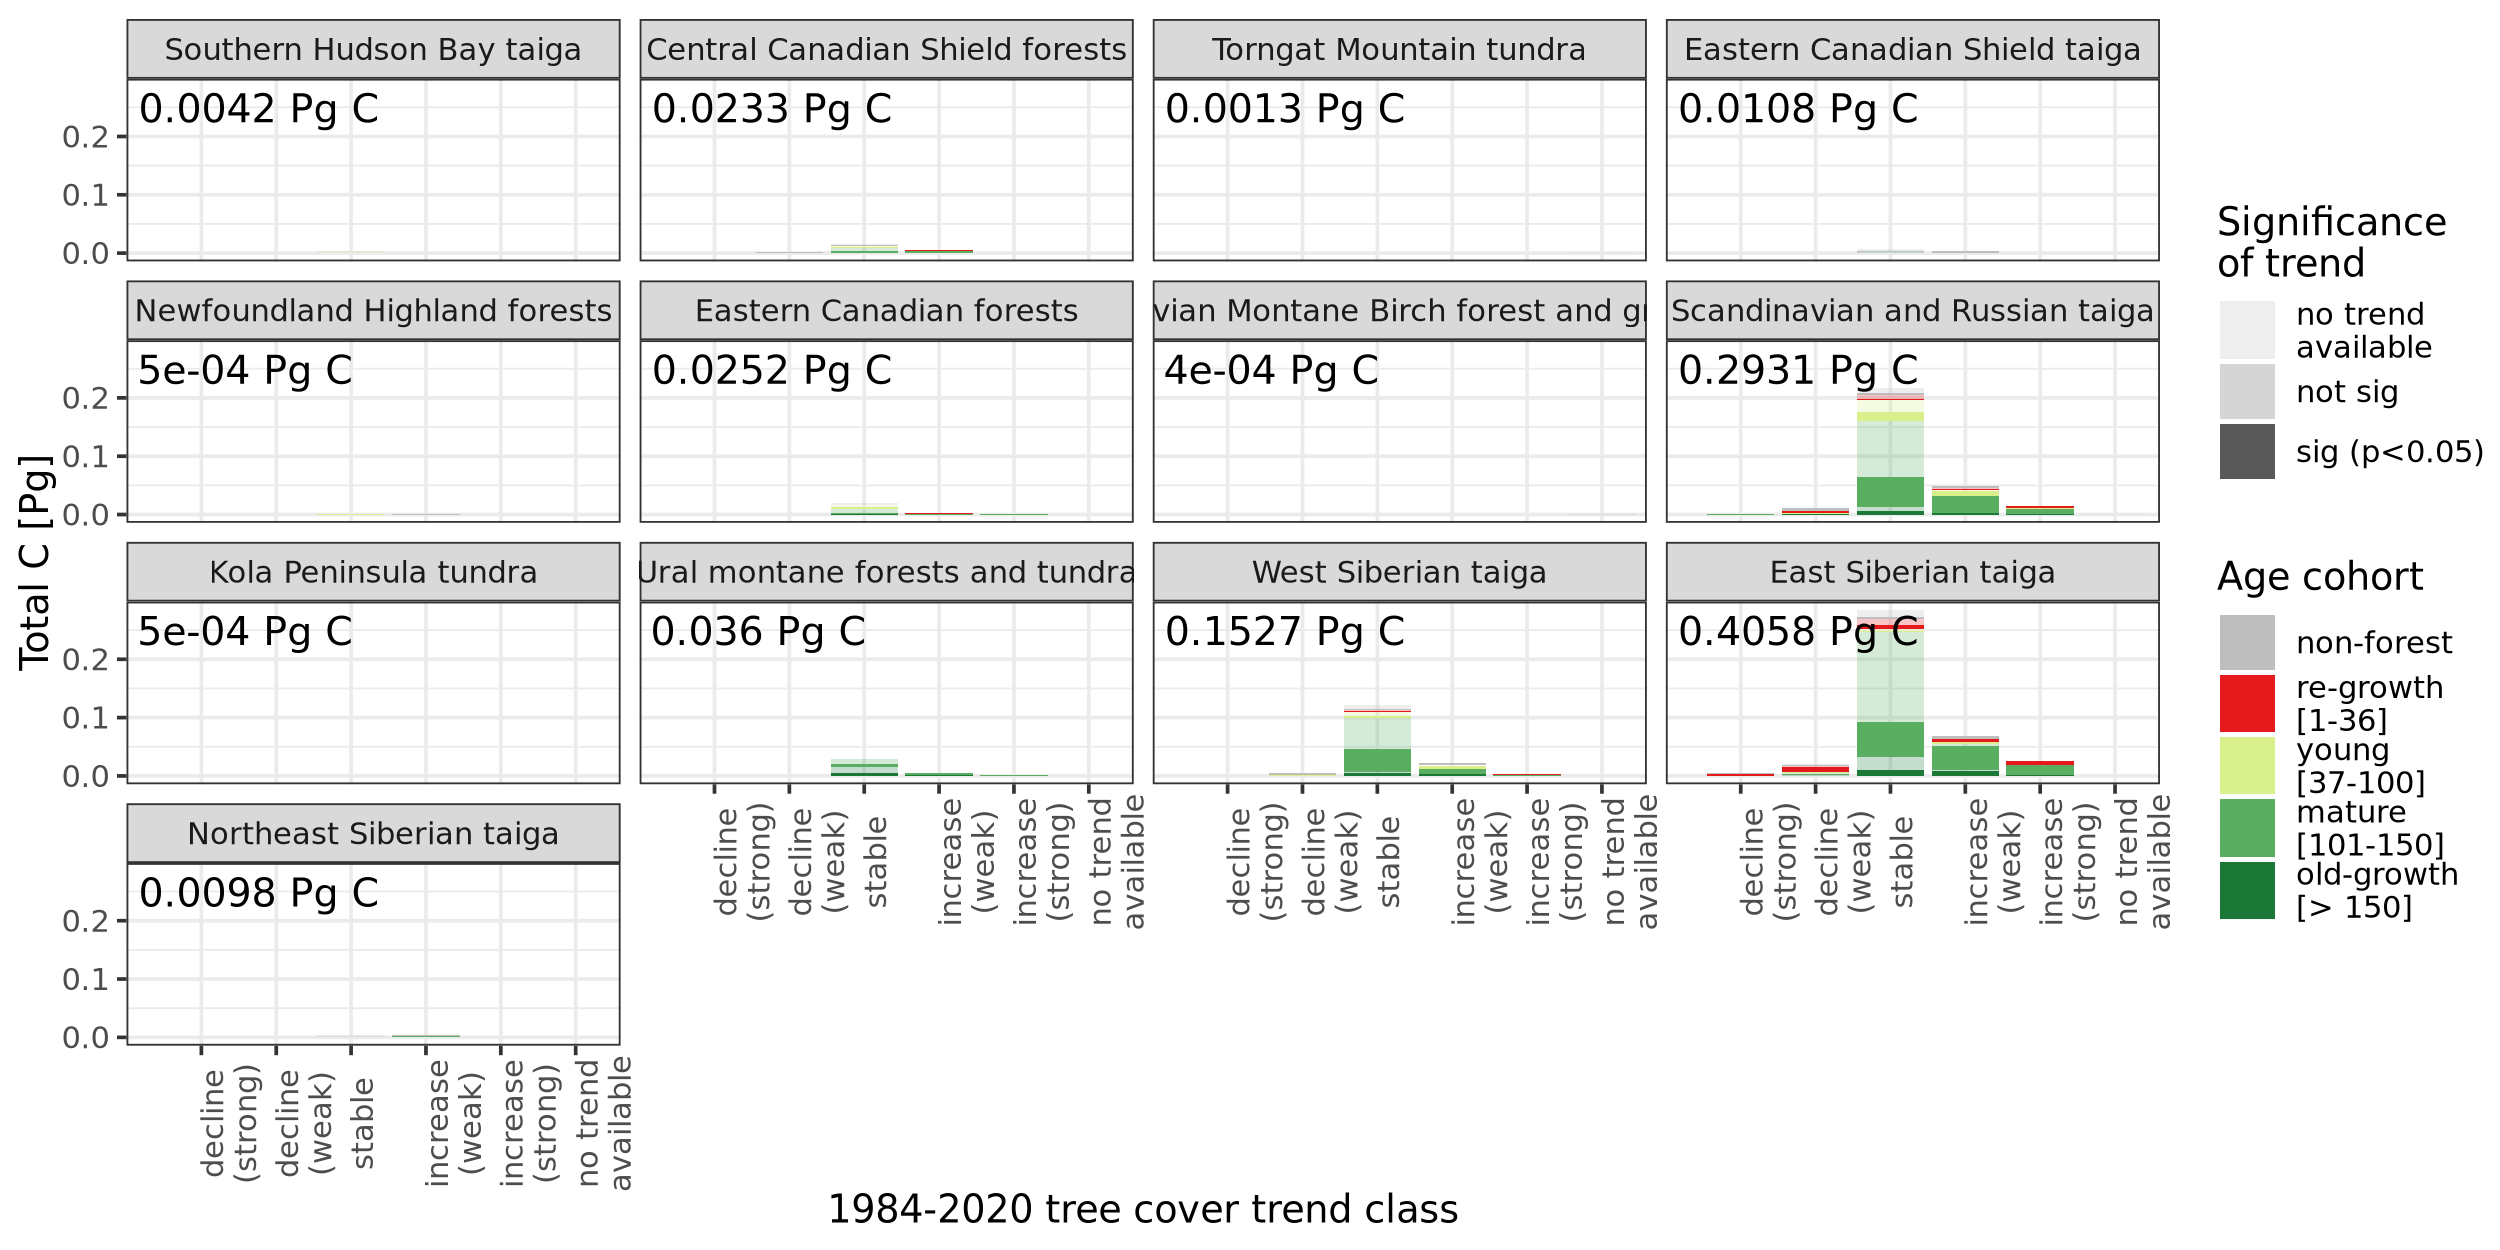

In [291]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 250)

p_bars_age_trend_pval = ggplot( ) +
    geom_bar(summary_df , mapping = aes( x=trend_class, y=total_carbon_Pg, fill=age_cohort, alpha=pvalue_class), stat='identity') + # for a regular bar plot - fast
    scale_fill_manual(values=age_colors, name='Age cohort')+ 
    scale_alpha_manual(values=pvalue_class_alpha, name='Significance\nof trend')+ 
    text_total_C_ecoregion +
    facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) + 
    theme_bw() +
    theme(axis.text.x = element_text(angle=90)) +
    labs(y='Total C [Pg]', x='1984-2020 tree cover trend class')
p_bars_age_trend_pval

# Distributions (can be from samples of pixel-level data):
### C accumulation of the mature, young, re-growth that are increasing vs decreasing

In [292]:
# Function to add count labels
add_count_labels <- function(p, count_data, Y_VAL=1.95) {
  p + geom_text(
    data = count_data,
    aes(label = paste0('n=',count), y = Y_VAL, angle = 90),  # Position near top of plot (0-2 range)
    position = position_dodge(width = 0.8),
    vjust = -0.5,
    size = 2.5
  )
}

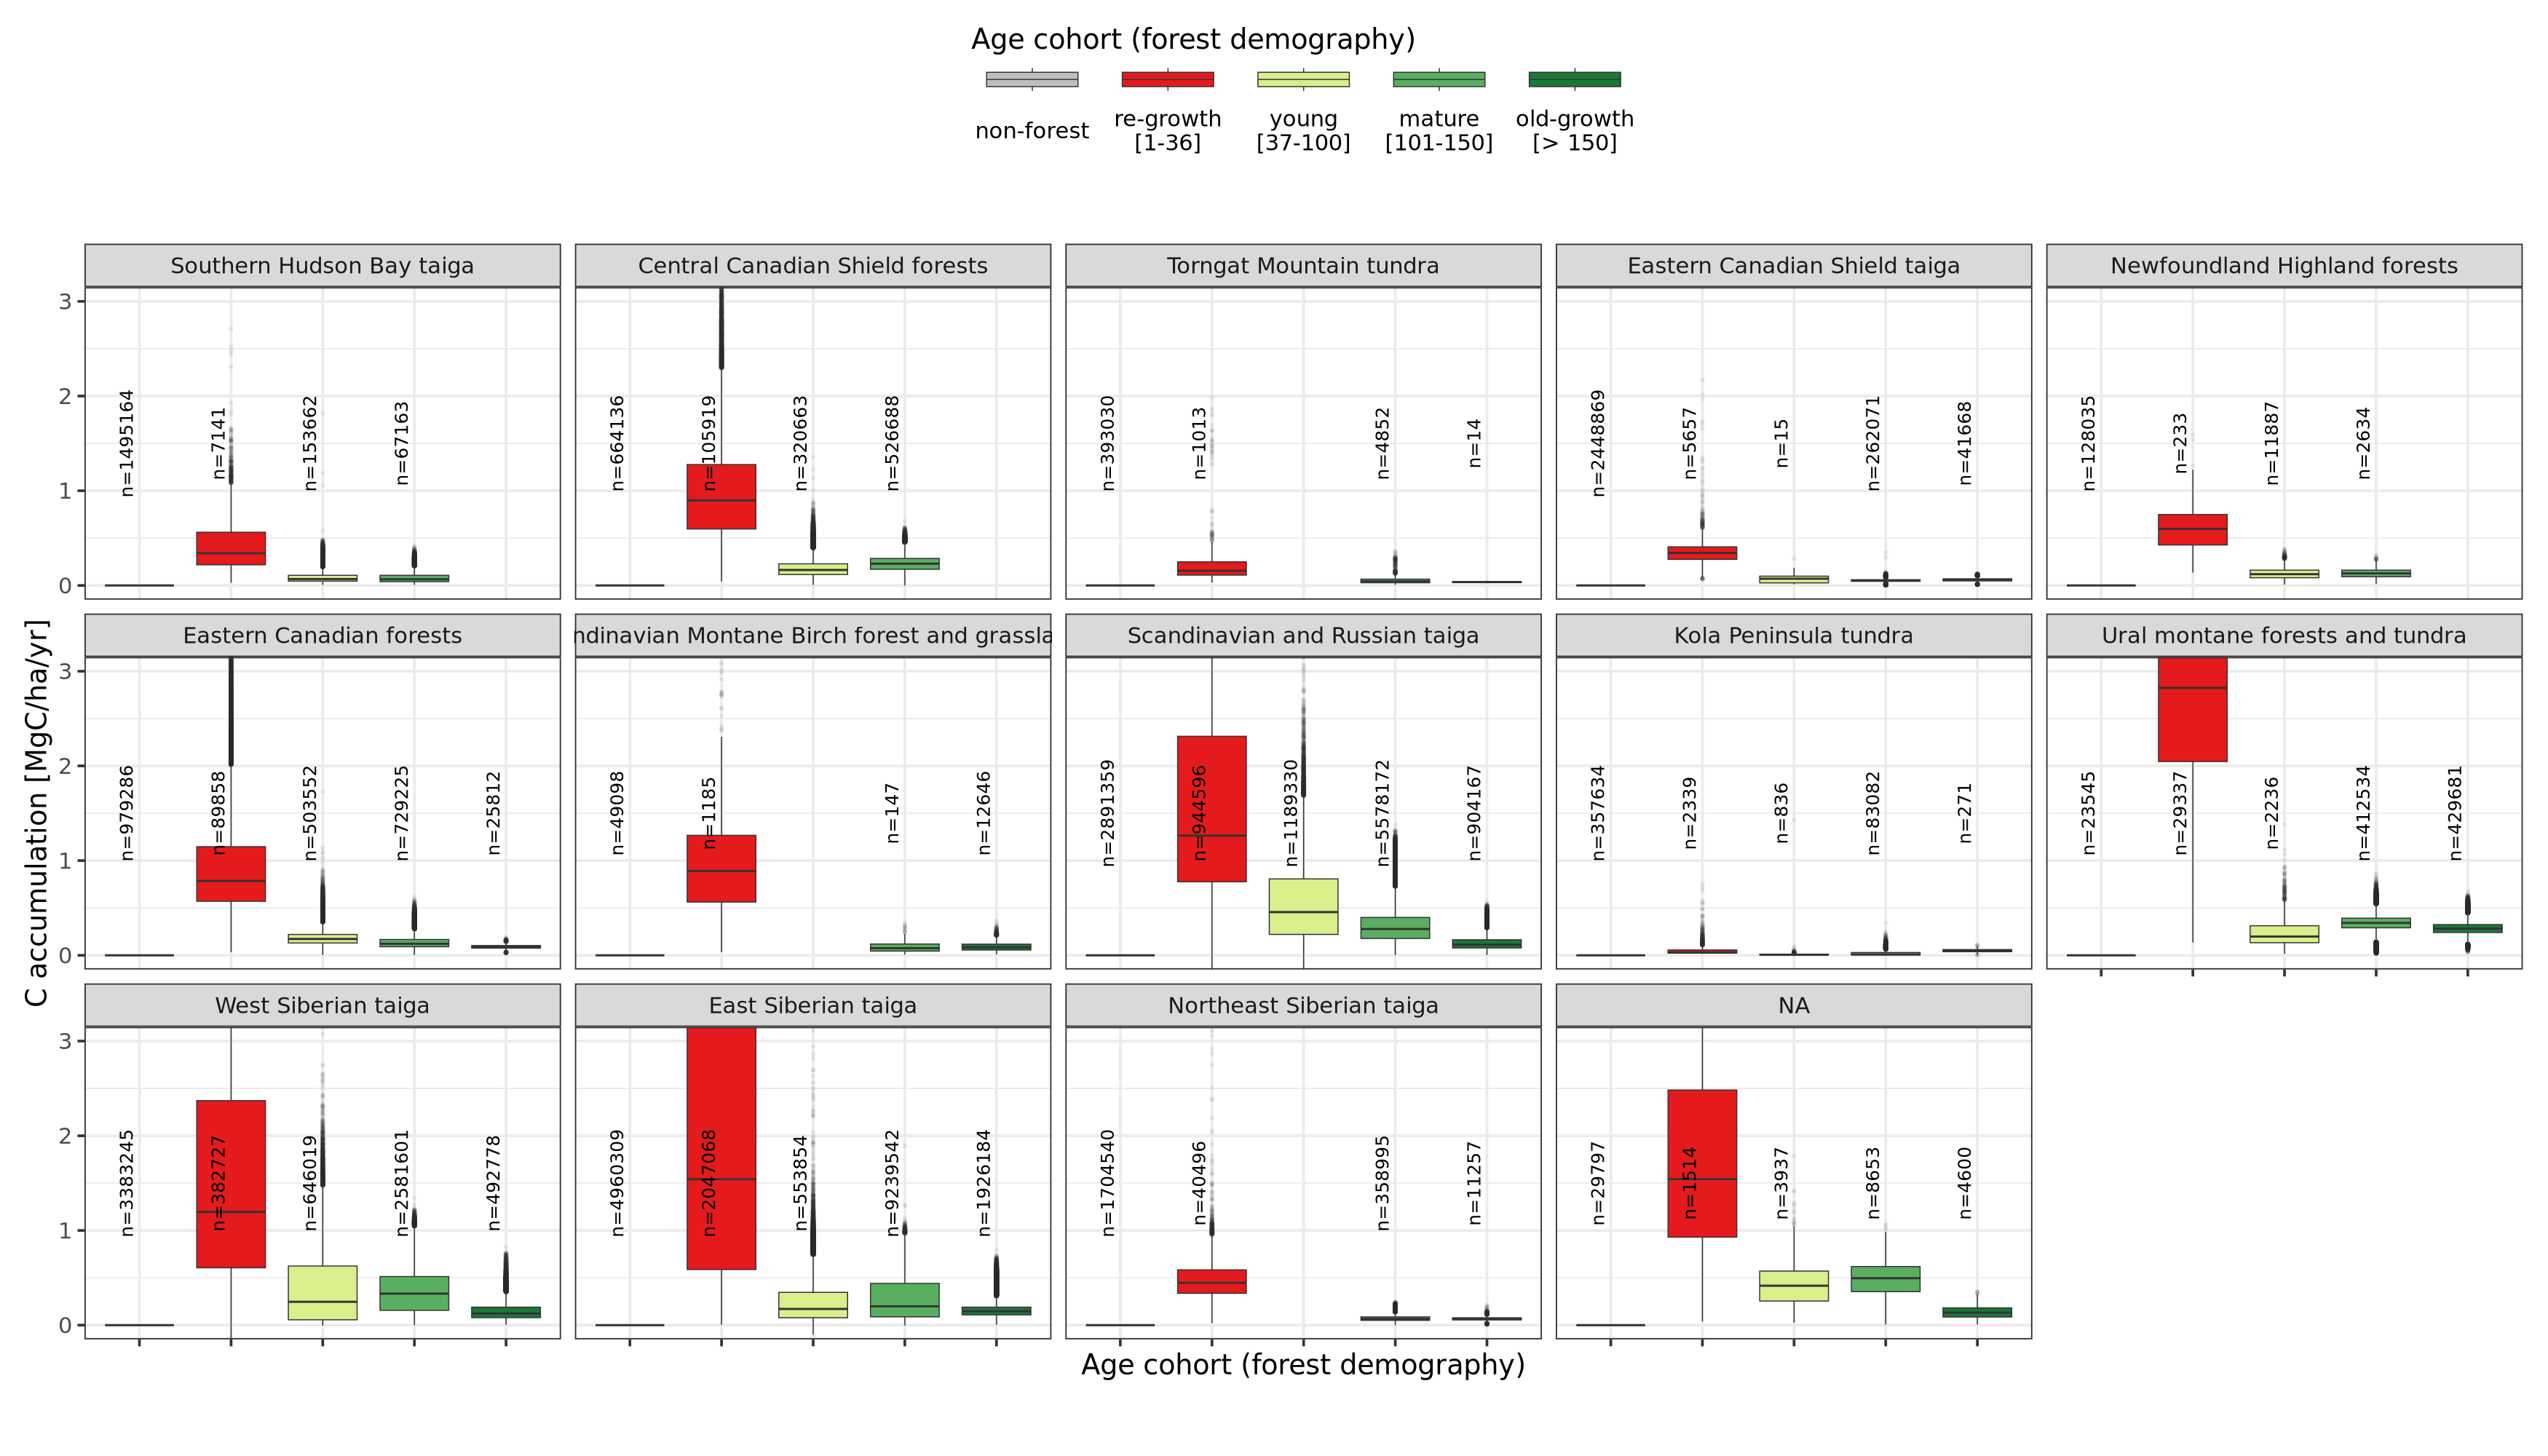

In [293]:
options(repr.plot.width = 14, repr.plot.height = 8, repr.plot.res = 250)

count_by_age_cohort <- pixel_df %>%
  group_by(age_cohort, ecoregions_ECO_NAME) %>%
  summarise(count = n(), .groups = 'drop')
count_by_ecoregion_age <- pixel_df %>%
  group_by(age_cohort, ecoregions_ECO_NAME) %>%
  summarise(count = n(), .groups = 'drop')

p_distrib_c_accum_all = ggplot(pixel_df  #%>% sample_frac(0.15) 
                               , aes( x=age_cohort, y=carbon_acc, fill=age_cohort) ) +
    geom_boxplot(outlier.size=0.25, outlier.alpha=0.05, linewidth=0.2) +
    coord_cartesian(ylim=c(0, 3)) +
    #scale_fill_manual(values=age_colors, name='Age cohort', guide="none")+ 
    facet_wrap(.~ecoregions_ECO_NAME, ncol=5) + 
    theme_bw() +
    #theme(axis.text.x = element_text(angle=90)) +
    geom_list_bars_age +
    labs(y='C accumulation [MgC/ha/yr]', x='Age cohort (forest demography)')

p_distrib_c_accum_all = add_count_labels(p_distrib_c_accum_all, count_by_ecoregion_age, Y_VAL=1.5)

p_distrib_c_accum_all

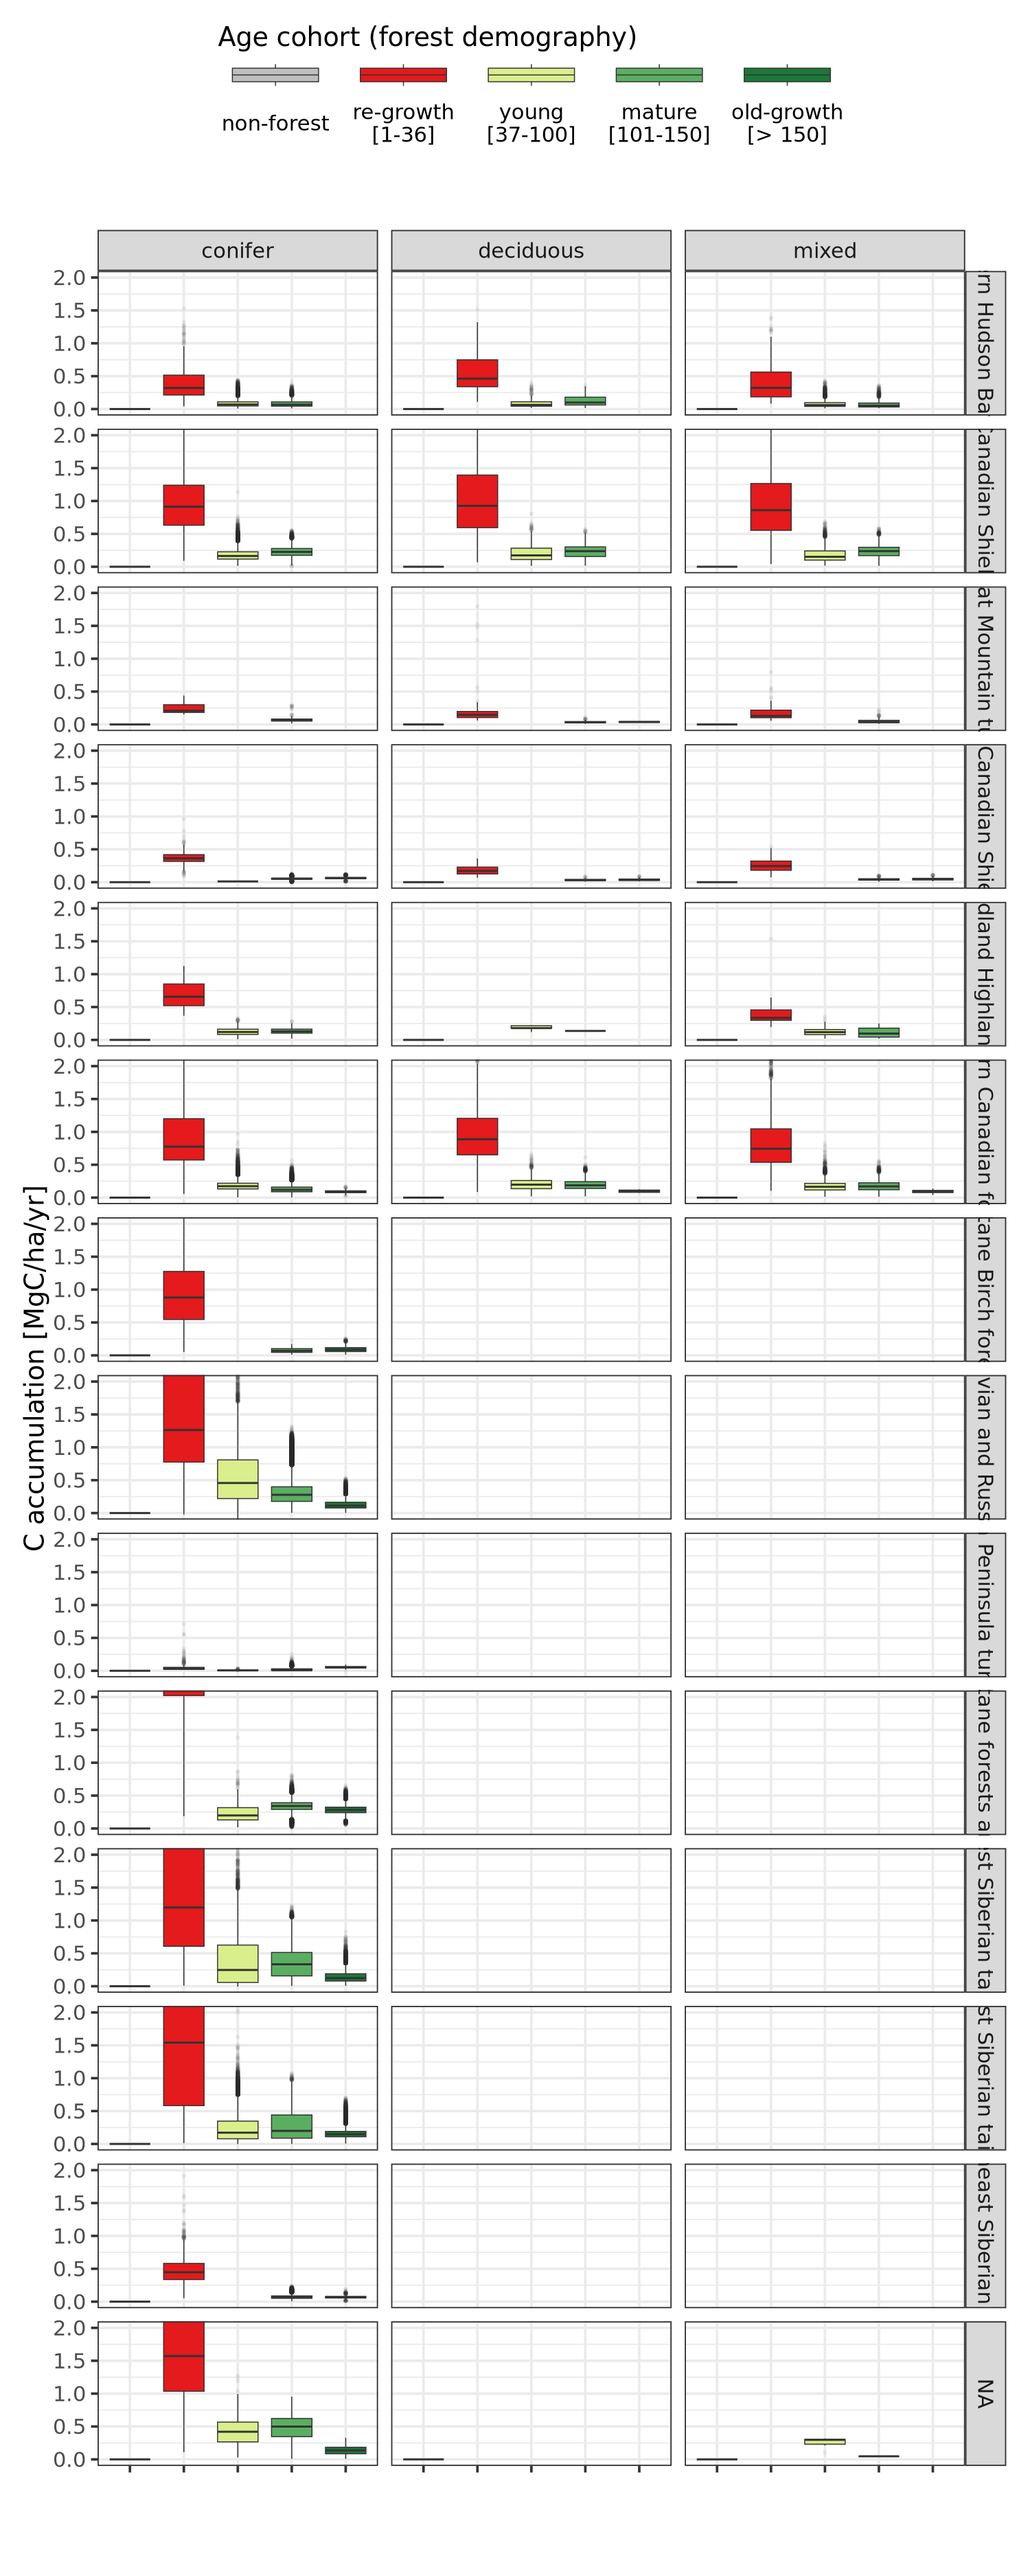

In [294]:
options(repr.plot.width = 6, repr.plot.height = 15, repr.plot.res = 250)

count_by_age_cohort <- pixel_df %>%
  group_by(age_cohort, ecoregions_ECO_NAME) %>%
  summarise(count = n(), .groups = 'drop')

p_distrib_c_accum_decid = ggplot(pixel_df  %>% sample_frac(0.15) , aes( x=age_cohort, y=carbon_acc, fill=age_cohort) ) +
    geom_boxplot(outlier.size=0.25, outlier.alpha=0.05, linewidth=0.2) +
    coord_cartesian(ylim=c(0, 2)) +
    #scale_fill_manual(values=age_colors, name='Age cohort', guide="none")+ 
    #facet_wrap(.~deciduous_class, ncol=4) + 
facet_grid(ecoregions_ECO_NAME ~ deciduous_class) +
    theme_bw() +
    #theme(axis.text.x = element_text(angle=90)) +
    geom_list_bars_age +
    labs(y='C accumulation [MgC/ha/yr]', x='')

#p_distrib_c_accum_decid = add_count_labels(p_violin_c_accum_all, count_by_age_cohort, Y_VAL=1.0)

p_distrib_c_accum_decid

Warning message:
“Removed 1323337 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


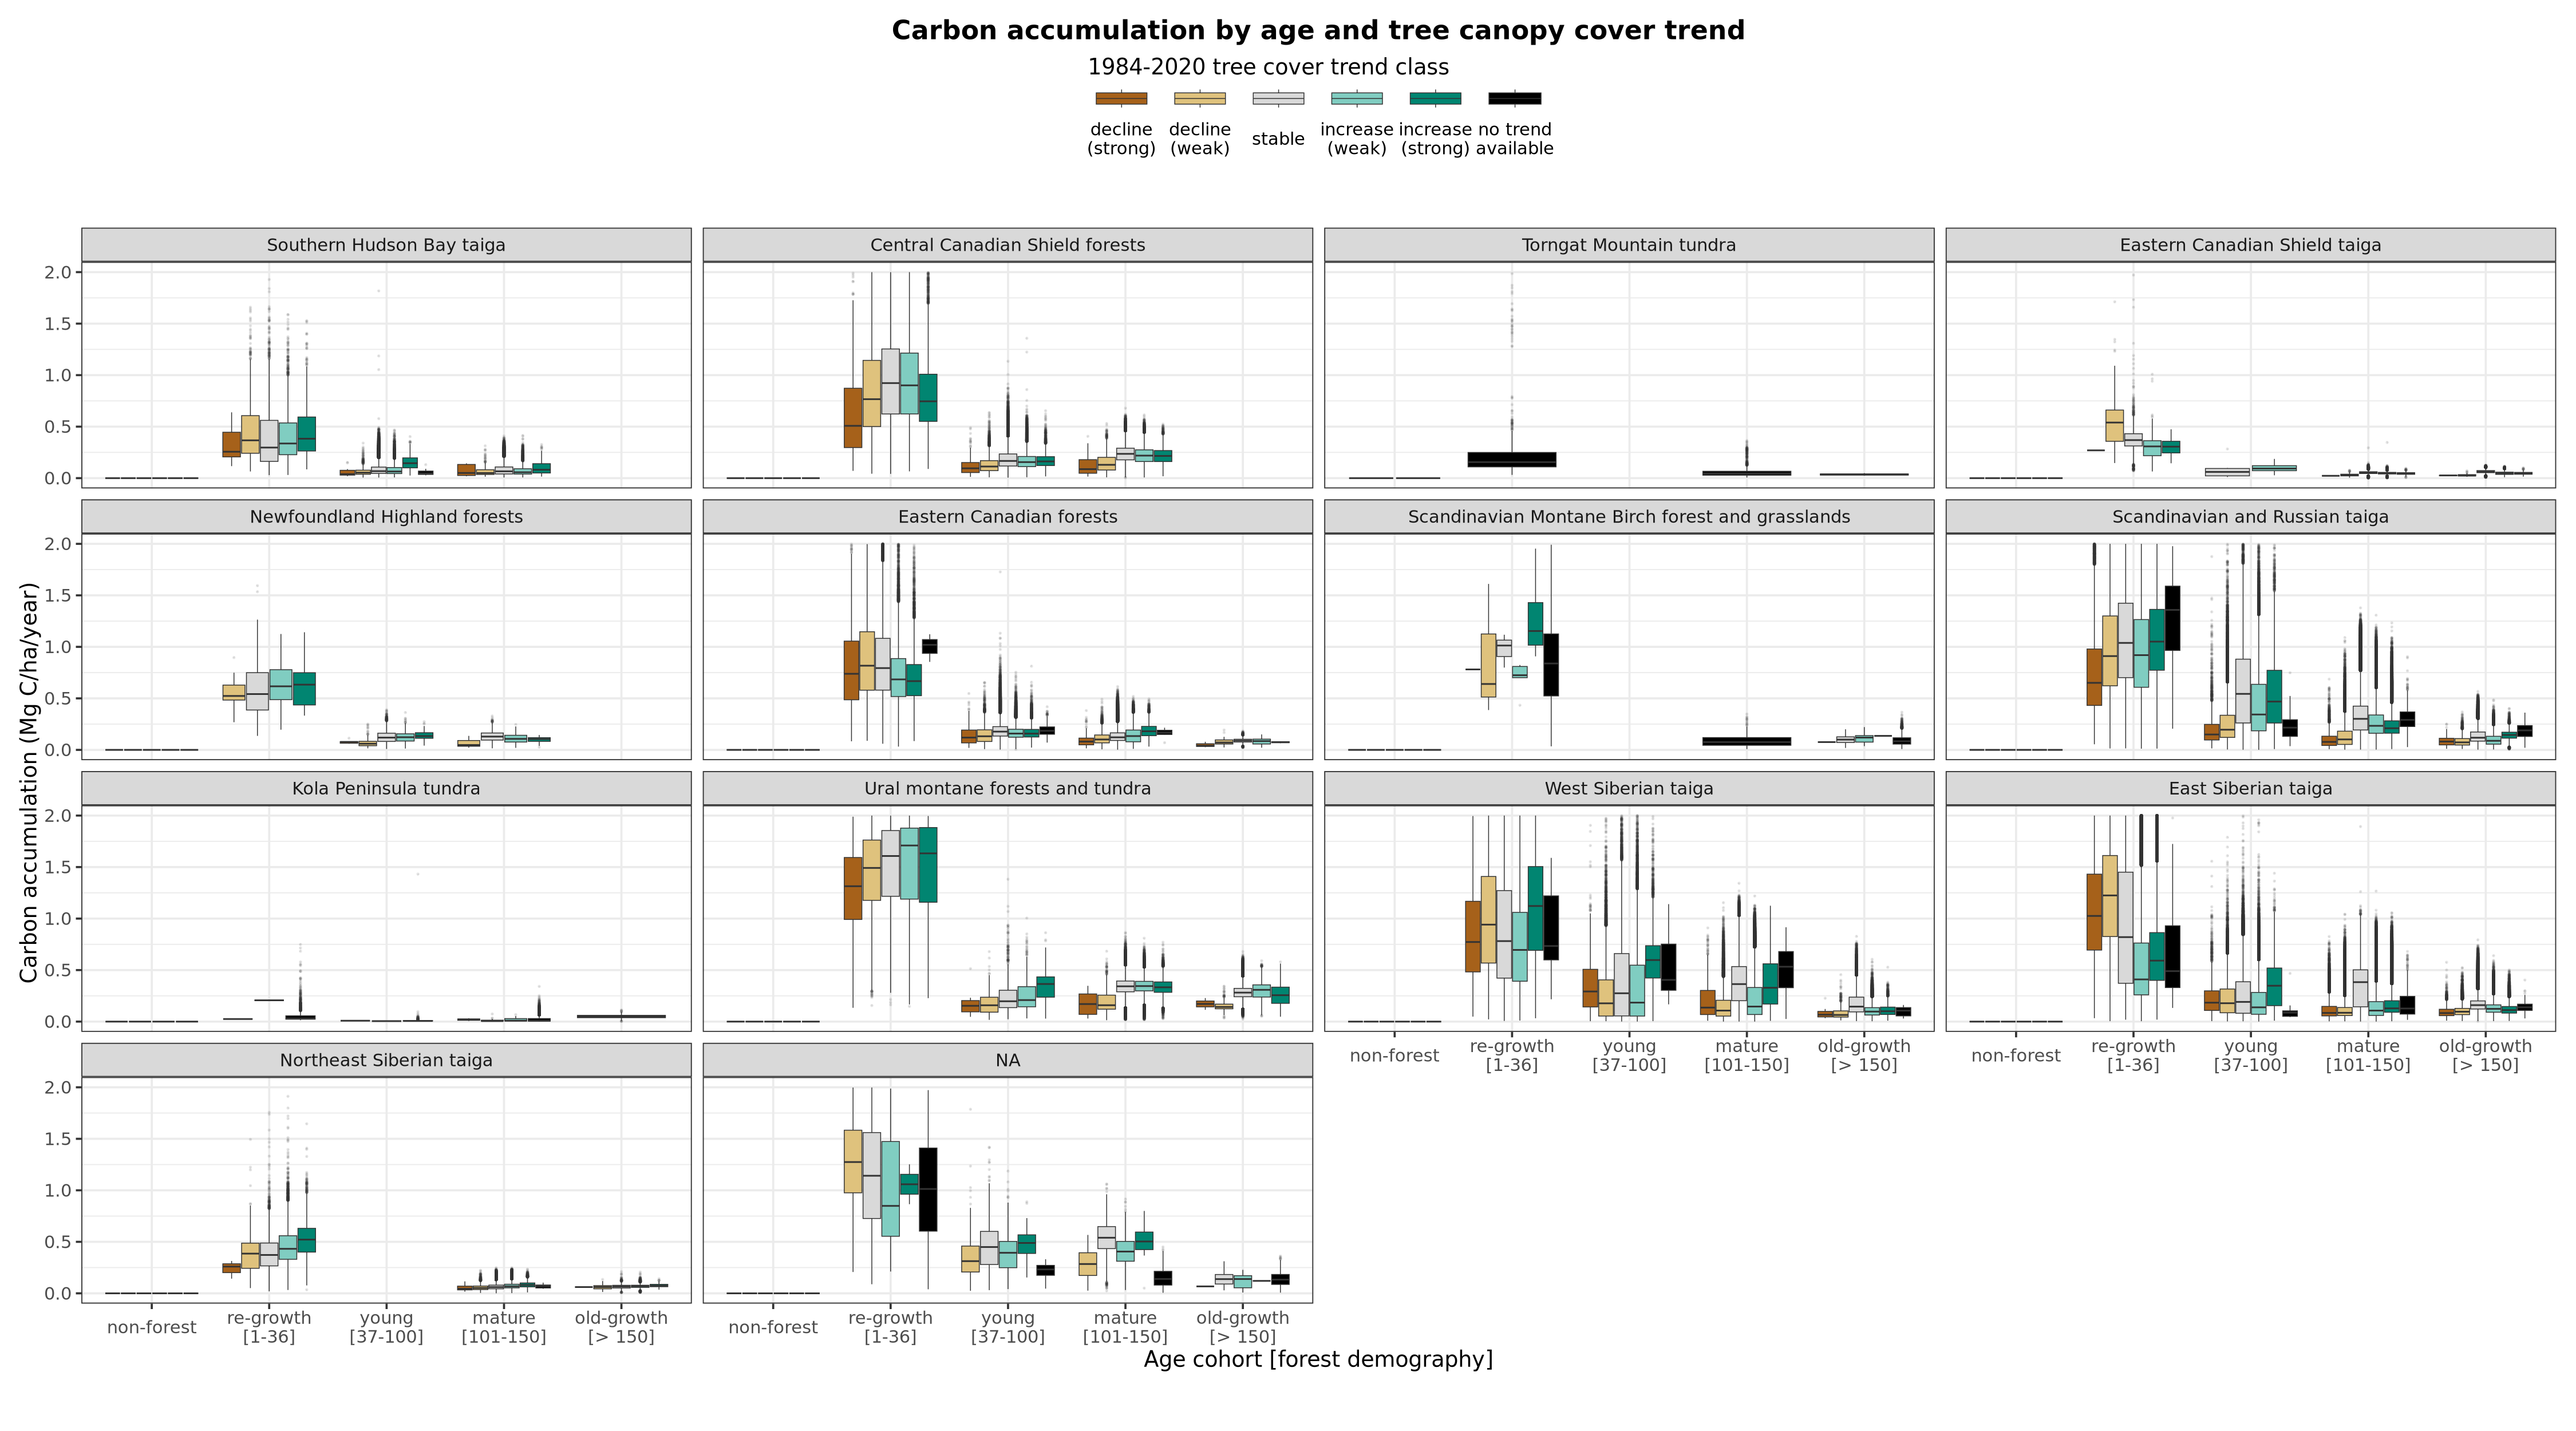

In [295]:
options(repr.plot.width = 18, repr.plot.height = 10, repr.plot.res = 250)

p1 <- ggplot(pixel_df #%>% sample_frac(0.0001)
             , aes(x = age_cohort, y = carbon_acc, fill = trend_class)) +
        geom_boxplot(position = position_dodge(width = 0.8), outlier.size = 0.1, outlier.alpha = 0.1, linewidth=0.2) +
        #scale_fill_manual(values = trend_colors) +
        labs(
            x = 'Age cohort [forest demography]',
            y = 'Carbon accumulation (Mg C/ha/year)',
            fill = '1984-2020\ntree cover\ntrend class',
            title = 'Carbon accumulation by age and tree canopy cover trend'
        ) +
        ylim(0, 2) +
        theme_bw() +
        geom_list_bars_trend +
        theme(
            axis.text.x = element_text(angle = 0, hjust = 0.5),
        ) +
        facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) 

# Add count labels
p1# <- add_count_labels(p1, count_by_age_trend)

In [296]:
levels(summary_df$ecoregions_ECO_NAME)

[1] "Southern Hudson Bay taiga"                       
 [2] "Central Canadian Shield forests"                 
 [3] "Torngat Mountain tundra"                         
 [4] "Eastern Canadian Shield taiga"                   
 [5] "Newfoundland Highland forests"                   
 [6] "Eastern Canadian forests"                        
 [7] "Scandinavian Montane Birch forest and grasslands"
 [8] "Scandinavian and Russian taiga"                  
 [9] "Kola Peninsula tundra"                           
[10] "Ural montane forests and tundra"                 
[11] "West Siberian taiga"                             
[12] "East Siberian taiga"                             
[13] "Northeast Siberian taiga"

### Specific ecoregion highlight

In [297]:
SPECIFIC_ECOREGION = 'Eastern forest-boreal transition'
SPECIFIC_ECOREGION = 'Scandinavian and Russian taiga'

Warning message:
“Removed 282443 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


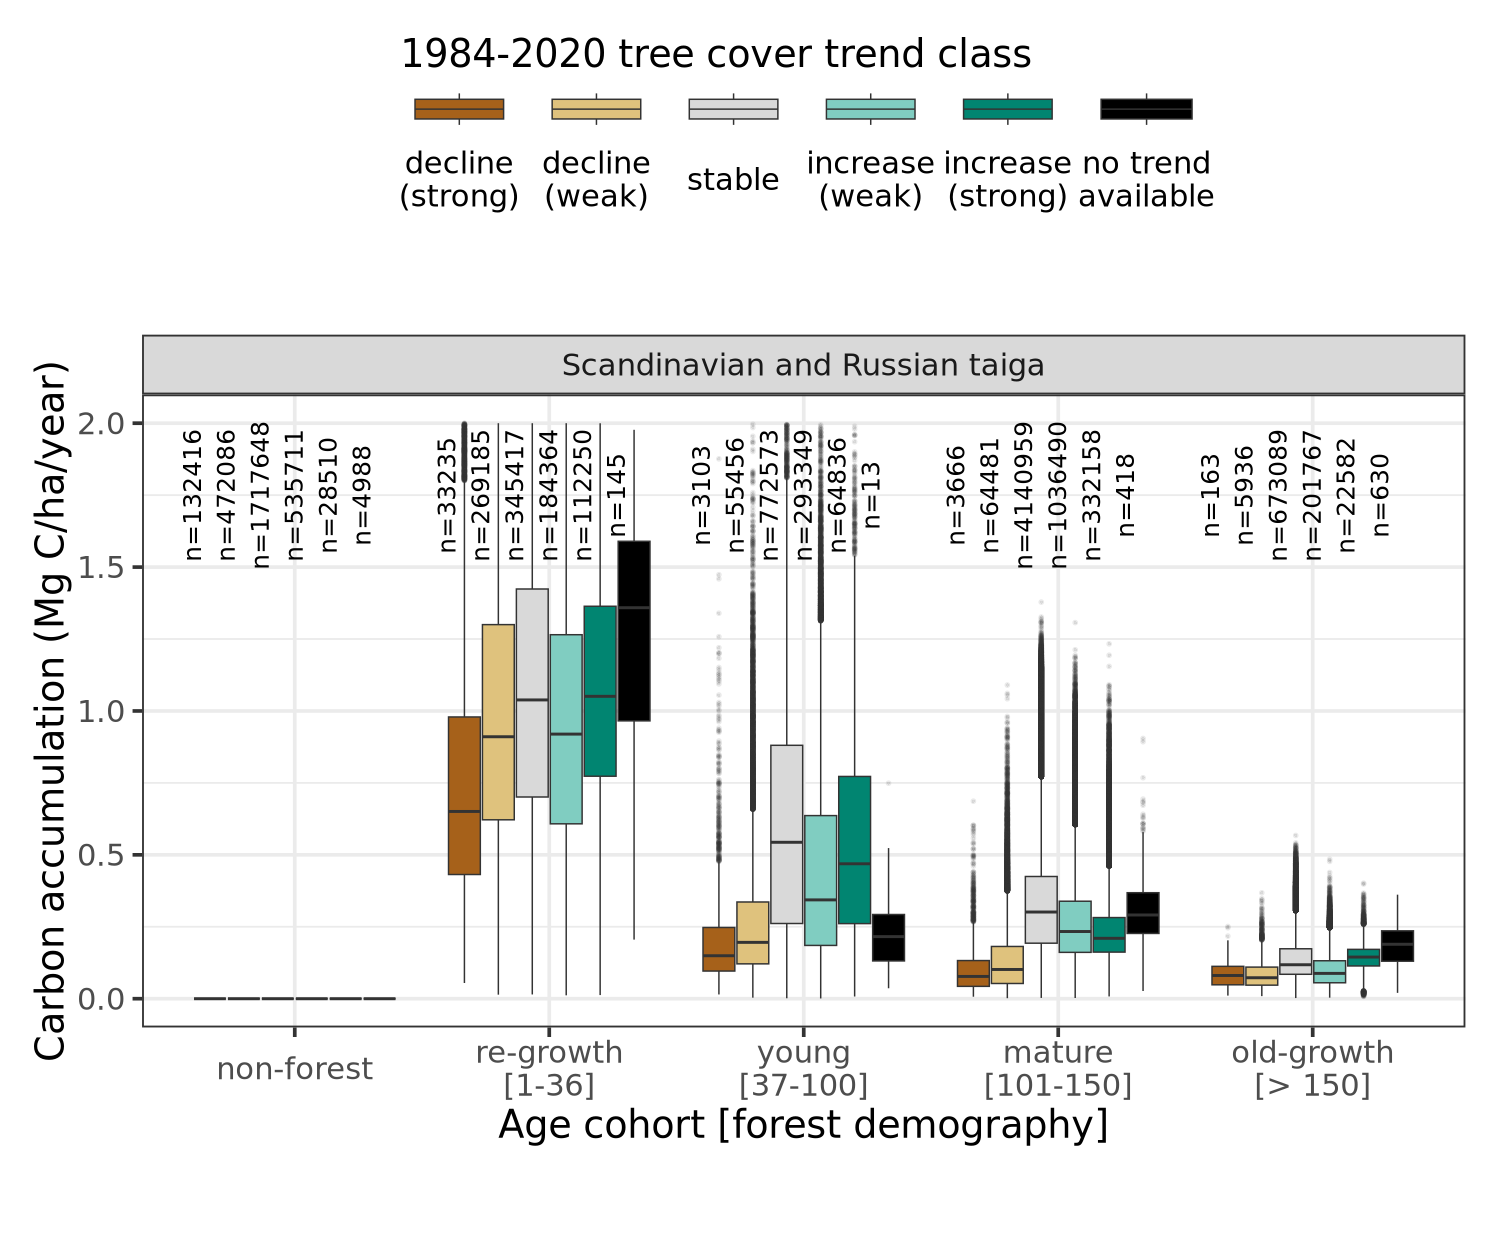

In [298]:
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 250)

count_by_ecoregion_age_trend <- pixel_df %>% 
    filter(ecoregions_ECO_NAME == SPECIFIC_ECOREGION) %>%
  group_by(trend_class, age_cohort, ecoregions_ECO_NAME) %>%
  summarise(count = n(), .groups = 'drop')

p1_subset <- ggplot(pixel_df %>% filter(ecoregions_ECO_NAME == SPECIFIC_ECOREGION)
             , aes(x = age_cohort, y = carbon_acc, fill = trend_class)) +
        geom_boxplot(position = position_dodge(width = 0.8), outlier.size = 0.1, outlier.alpha = 0.1, linewidth=0.2) +
        #scale_fill_manual(values = trend_colors) +
        labs(
            x = 'Age cohort [forest demography]',
            y = 'Carbon accumulation (Mg C/ha/year)',
            fill = '1984-2020\ntree cover\ntrend class',
            #title = 'Carbon accumulation by age and tree canopy cover trend'
        ) +
        ylim(0, 2) +
        theme_bw() +
        geom_list_bars_trend +
        theme(
            axis.text.x = element_text(angle = 0, hjust = 0.5),
        ) +
        facet_wrap(.~ ecoregions_ECO_NAME, ncol=4) 

# Add count labels
p1_subset <- add_count_labels(p1_subset, count_by_ecoregion_age_trend, Y_VAL = 1.75)
p1_subset

Warning message:
“Removed 1125044 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


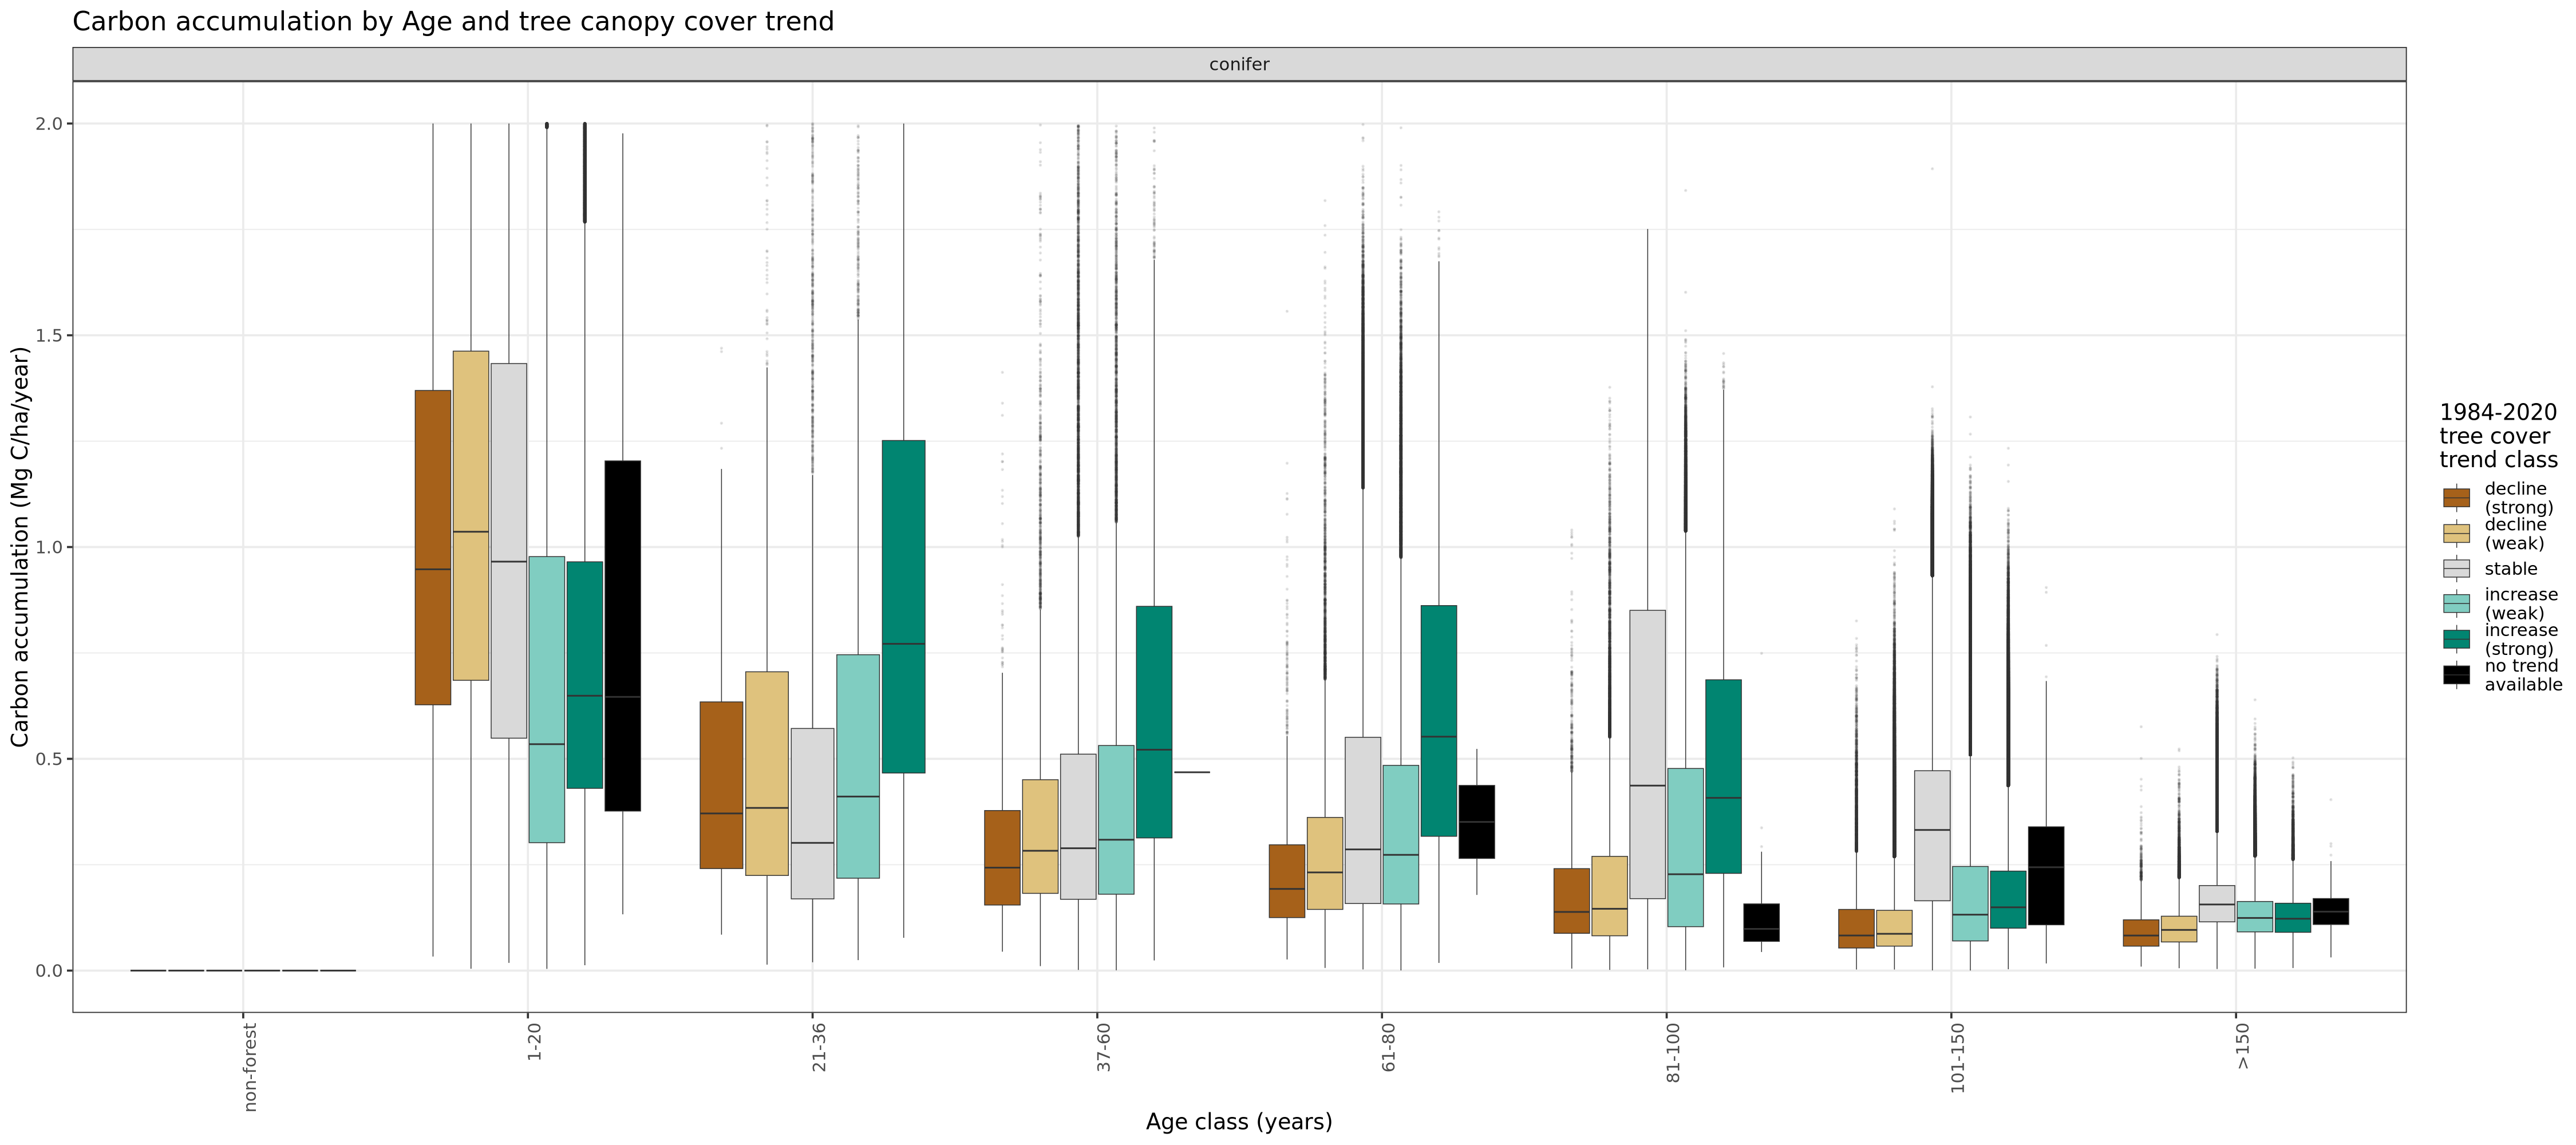

In [178]:
options(repr.plot.width = 18, repr.plot.height = 8, repr.plot.res = 250)

p1_decid <- ggplot(pixel_df, aes(x = age_class, y = carbon_acc, fill = trend_class)) +
        geom_boxplot(position = position_dodge(width = 0.8), outlier.size = 0.1, outlier.alpha = 0.1, linewidth=0.2) +
        scale_fill_manual(values = trend_colors) +
        labs(
        x = 'Age class (years)',
        y = 'Carbon accumulation (Mg C/ha/year)',
        fill = '1984-2020\ntree cover\ntrend class',
        title = 'Carbon accumulation by age & tree canopy cover trend'
        ) +
        ylim(0, 2) +
        theme_bw() +
        theme(
        axis.text.x = element_text(angle = 90, hjust = 1),
        ) +
        facet_wrap(.~ deciduous_class, ncol=4)

# Add count labels
p1_decid# <- add_count_labels(p1, count_by_age_trend)

## Misc practice below

### This is almost working - sizes dont match correctly UNLESS everything is in a single row

In [ ]:
create_donut_update <- function(summary_df, id_value){
    
    # Filter data for this ID
    summary_df <- summary_df %>% 
        filter(ID == id_value)

    # Just to check total
    smry = summary_df %>% group_by(ID) %>% summarize(sum_total_C_Pg = sum(total_carbon_Pg))
    
    ggplot() +
        geom_rect(summary_df, mapping=aes(ymax=ymax, ymin=ymin, xmax=4, xmin=3, fill=age_cohort), show.legend=FALSE) + 
        scale_fill_manual(values=age_colors) +
        coord_polar(theta = "y", start = 0) +
        #xlim(c(1, 4)) +
        # Add center annotation showing total carbon
          # geom_text(aes(
          #   x = 0.2,  # Position text in center
          #   y = 0,    # Any value works as we're not using this dimension
          #   label = paste0("Total C:\n", round(sum(total_carbon_Pg), 7), " Pg")
          #     ), size = 4) +
          geom_text(data=smry, mapping=aes(
            x = 0.2,  # Position text in center
            y = 0,    # Any value works as we're not using this dimension
            label = paste0("Total C:\n", round(sum_total_C_Pg, 4), " Pg\ntile: ", ID)
              ), size = 4) +
        # geom_text(data=smry, mapping=aes(
        #     x = -2,  # Position text in center
        #     y = 1,    # Any value works as we're not using this dimension
        #     label = paste0("tile: ", ID)
        #       ), size = 3, color='grey10') +
    theme_void() +
    theme(
      legend.position = "none",
      plot.title = element_text(hjust = 0.5)
    ) #+ labs(title = id_value)
    }

In [116]:
plot_list = list()
size_factor_list = list()
id_list = list()

# First, calculate totals as before
totals = summary_df %>% group_by(ID) %>% summarize(Total_C = sum(total_carbon_Pg))

for(i in seq_along(unique(summary_df$ID))){
    
    id = unique(summary_df$ID)[i]
    df = summary_df[which(summary_df$ID == id), ]
    
    # Get the total C for this ID
    total_c <- totals$Total_C[totals$ID == id]
    
    # Set plot size based on total C
    size_factor <- total_c / max(totals$Total_C)
    #print(paste0('Tile_num: ',id,' , SF: ', size_factor))
    size_factor_list[[i]] = size_factor * 10
    id_list[[i]] = id
                          
    # Create the plot with appropriate size
    plot_list[[i]] = create_donut_update(df, id)
    }



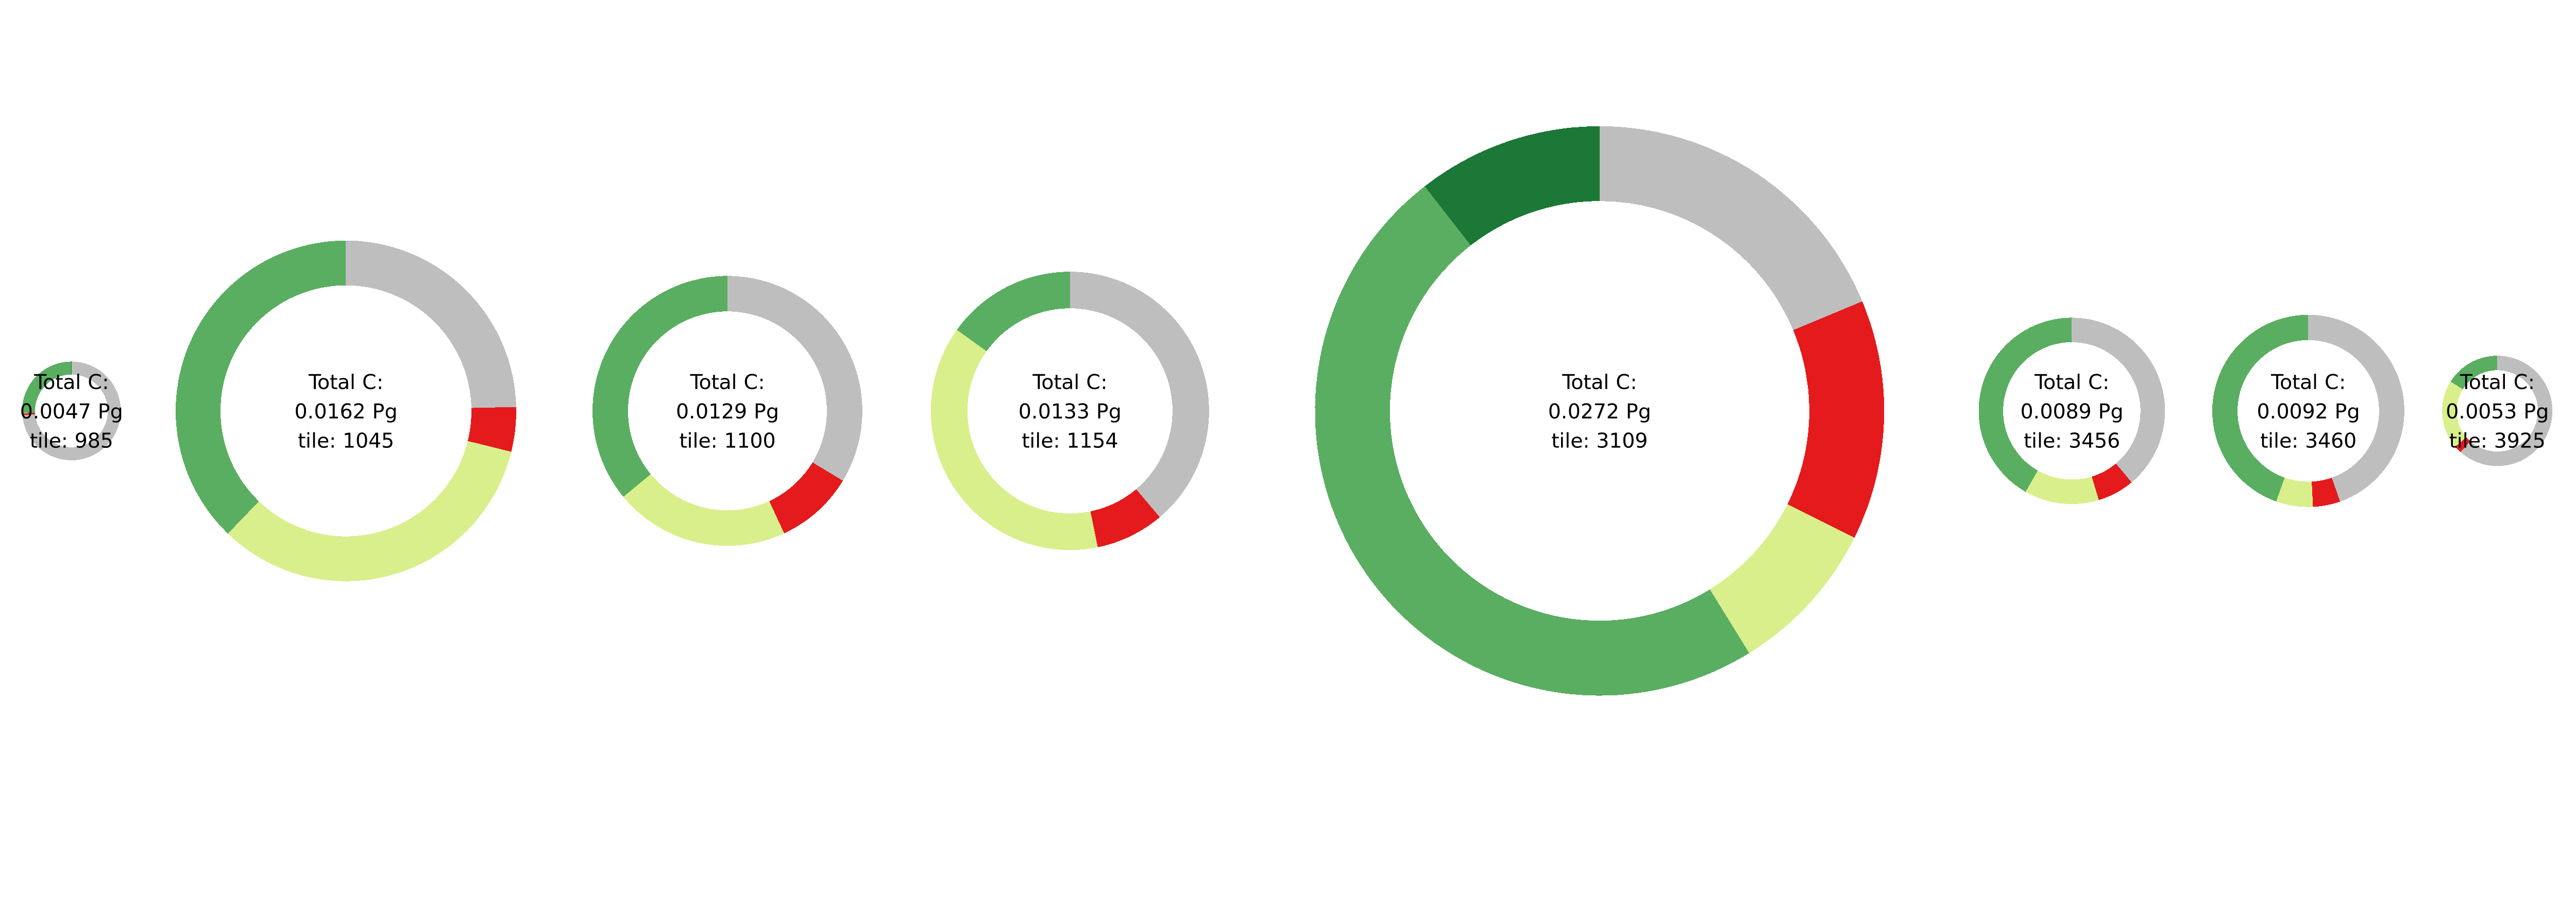

In [117]:
options(repr.plot.width = 20, repr.plot.height = 7, repr.plot.res = 250)

# Combine the plots - basic arrangement
combined_plot <- wrap_plots(plot_list, ncol = 8) +
    plot_layout(widths = size_factor_list, heights = size_factor_list)

# # Add overall title and shared legend
# legend_plot <- ggplot(summary_df) +
#   geom_rect(aes(xmin = 0, xmax = 1, ymin = 0, ymax = 1, fill = age_cohort)) +
#     scale_fill_manual(values=age_colors) +
#   theme_void() +
#   theme(legend.position = "bottom")

final_plot <- combined_plot + #/ 
  #guide_area() + 
  plot_layout(guides = "collect"
              , heights = c(10,1)
             )

# Add title
final_plot + 
  plot_annotation(
    #title = "Carbon Distribution by Age Class",
    #subtitle = "Donut size represents total carbon stock (Pg C)",
    theme = theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
                  plot.subtitle = element_text(size = 12, hjust = 0.5))
  )